# The main code for ML

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
from scipy.stats import pearsonr
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')


plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 9,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.linewidth': 1.0,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#2E6BA4', '#A8D8F0', '#7FBC8F', '#E89DB4', '#C8A2D0', '#F4A86B', '#5A8C7B', '#D4A373']
PRIMARY = '#2E6BA4'
PINK = '#E89DB4'
LIGHT = '#A8D8F0'


BASE_DIR = Path('.')
DATA_PATH = BASE_DIR / 'dataset.csv'
OUT_DIR = BASE_DIR / 'results/analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_SPLITS = 5
N_REPEAT_SEEDS = 10

print('DATA_PATH =', DATA_PATH)
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Not found {DATA_PATH}')

DATA_PATH = dataset.csv


## 1. Utility functions

In [ ]:
# Feature engineering functions
def extract_m1m2(comp):
    '''
    Extract M1 and M2 from the 'Compounds(M1-M2-N)' string. 
    If the format is unexpected, return 'UNK' for missing parts.
    '''
    parts = [p.strip() for p in str(comp).replace(' ', '').split('-')]
    m1 = parts[0] if len(parts) > 0 and parts[0] else 'UNK'
    m2 = parts[1] if len(parts) > 1 and parts[1] else 'UNK'
    return m1, m2

def build_feature_frame(df_in):
    '''
    Build feature matrix from input DataFrame.
    '''
    df = df_in.copy()

    physical_cols = [
        c for c in df.columns
        if c not in ['Overpotential(V)', 'data_source', 'Compounds(M1-M2-N)', 'Original_Compounds',
                     'Cycling_performance', 'cycling_performance']
    ]
    for col in physical_cols:
        if df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col], errors='coerce')

    X_phys = df[physical_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    compounds = df['Compounds(M1-M2-N)'].fillna('Unknown').astype(str).values
    m1_list = [extract_m1m2(c)[0] for c in compounds]
    m2_list = [extract_m1m2(c)[1] for c in compounds]
    m1_hot = pd.get_dummies(pd.Series(m1_list), prefix='m1')
    m2_hot = pd.get_dummies(pd.Series(m2_list), prefix='m2')

    X = pd.concat([X_phys.reset_index(drop=True), m1_hot.reset_index(drop=True), m2_hot.reset_index(drop=True)], axis=1)
    y = pd.to_numeric(df['Overpotential(V)'], errors='coerce').values
    groups = df['data_source'].fillna('Unknown').astype(str).values

    element_cols = [c for c in X.columns if c.startswith('m1_') or c.startswith('m2_')]
    return X, y, groups, physical_cols, element_cols


# Group-aware cross-validation functions
def make_group_splits(groups, n_splits=5, seed=42):
    '''
    Make group splits for cross-validation.
    '''
    unique_groups = np.unique(groups)
    if len(unique_groups) < 2:
        raise ValueError('Need at least 2 unique groups for GroupKFold')
    n_splits = min(n_splits, len(unique_groups))
    rng = np.random.default_rng(seed)
    shuffled = unique_groups.copy()
    rng.shuffle(shuffled)
    fold_groups = np.array_split(shuffled, n_splits)
    indices = np.arange(len(groups))
    splits = []
    for grp in fold_groups:
        val_mask = np.isin(groups, grp)
        va = indices[val_mask]
        tr = indices[~val_mask]
        splits.append((tr, va))
    return splits


# Model evaluation and tuning functions
def evaluate_estimator(estimator, X, y, splits):
    '''
    Evaluate the estimator using the provided splits.
    '''
    fold_scores = []
    oof_pred = np.zeros(len(y))
    cv_pred_rows = []
    for fold_idx, (tr, va) in enumerate(splits):
        est = clone(estimator)
        est.fit(X.iloc[tr], y[tr])

        pred_tr = est.predict(X.iloc[tr])
        pred_va = est.predict(X.iloc[va])

        oof_pred[va] = pred_va
        fold_scores.append(r2_score(y[va], pred_va))

        cv_pred_rows.append(pd.DataFrame({
            'fold': fold_idx,
            'sample_idx': tr,
            'set_type': 'train',
            'y_true': y[tr],
            'y_pred': pred_tr,
        }))
        cv_pred_rows.append(pd.DataFrame({
            'fold': fold_idx,
            'sample_idx': va,
            'set_type': 'test',
            'y_true': y[va],
            'y_pred': pred_va,
        }))

    if len(cv_pred_rows) > 0:
        cv_pred_df = pd.concat(cv_pred_rows, ignore_index=True)
    else:
        cv_pred_df = pd.DataFrame(columns=['fold', 'sample_idx', 'set_type', 'y_true', 'y_pred'])

    return np.array(fold_scores), oof_pred, cv_pred_df

def tune_one_model(name, estimator, param_grid, X, y, groups, seed=42):
    splits = make_group_splits(groups, n_splits=N_SPLITS, seed=seed)
    search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=splits,
        scoring='r2',
        n_jobs=-1,
        refit=True
    )
    search.fit(X, y)
    best_est = search.best_estimator_
    fold_scores, oof_pred, cv_pred_df = evaluate_estimator(best_est, X, y, splits)
    return {
        'name': name,
        'best_params': search.best_params_,
        'grid_best_score': float(search.best_score_),
        'cv_mean_r2': float(np.mean(fold_scores)),
        'cv_std_r2': float(np.std(fold_scores)),
        'best_estimator': best_est,
        'oof_pred': oof_pred,
        'cv_pred_df': cv_pred_df,
        'splits': splits
    }

In [3]:
# Load dataset and build features
df = pd.read_csv(DATA_PATH)
X, y, groups, physical_cols, element_cols = build_feature_frame(df)
# Save intermediate dataset with engineered features for later analysis
df.to_csv(Path('./results/analysis/dataset_with_engineered_features.csv'), index=False, encoding='utf-8-sig')

# 2. Overpotential & Cycling_performance relationship

Pearson r=-0.418, p=7.373e-10
Spearman rho=-0.403, p=3.244e-09
Kendall tau=-0.284, p=5.295e-09


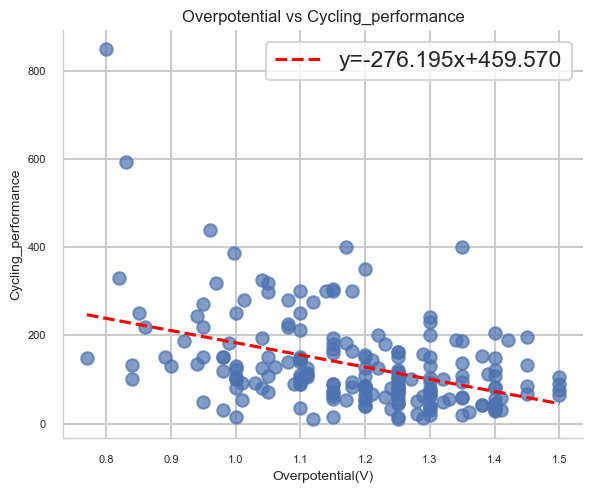

Co-Ni subset sample count: 19
Co-Ni mean Cycling_performance: 232.0
Bootstrap Pearson r mean=-0.418, 95% CI=(-0.523, -0.284)
Saved to： results\analysis\overpotential_vs_cycling.csv


In [6]:
# Overpotential and Cycling_performance relationship analysis
if 'Cycling_performance' not in df.columns:
    df = pd.read_csv(Path('./results/analysis/dataset_with_engineered_feature.csv'))
ov = pd.to_numeric(df['Overpotential(V)'], errors='coerce')
cp = pd.to_numeric(df['Cycling_performance'], errors='coerce')
mask = ov.notna() & cp.notna()
df_rel = df.loc[mask].copy()

if len(df_rel) == 0:
    print('No valid data for Cycling_performance, skipping analysis')
else:
    # Corelations：Pearson / Spearman / Kendall
    from scipy.stats import spearmanr, kendalltau
    p_r, p_p = pearsonr(df_rel['Overpotential(V)'], df_rel['Cycling_performance'])
    s_r = spearmanr(df_rel['Overpotential(V)'], df_rel['Cycling_performance'])
    k_r = kendalltau(df_rel['Overpotential(V)'], df_rel['Cycling_performance'])
    print(f"Pearson r={p_r:.3f}, p={p_p:.3e}")
    print(f"Spearman rho={s_r.correlation:.3f}, p={s_r.pvalue:.3e}")
    print(f"Kendall tau={k_r.correlation:.3f}, p={k_r.pvalue:.3e}")

    # Scatter plot with linear fit
    plt.figure(figsize=(6, 5))
    plt.scatter(df_rel['Overpotential(V)'], df_rel['Cycling_performance'], alpha=0.7)
    m, b = np.polyfit(df_rel['Overpotential(V)'], df_rel['Cycling_performance'], 1)
    xs = np.linspace(df_rel['Overpotential(V)'].min(), df_rel['Overpotential(V)'].max(), 100)
    plt.plot(xs, m * xs + b, color='red', linestyle='--', label=f'y={m:.3f}x+{b:.3f}')
    plt.xlabel('Overpotential(V)')
    plt.ylabel('Cycling_performance')
    plt.title('Overpotential vs Cycling_performance')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'overpotential_vs_cycling_scatter.png', dpi=180, bbox_inches='tight')
    plt.show()


    # Co-Ni subset analysis
    compounds = df_rel['Compounds(M1-M2-N)'].fillna('').astype(str)
    m1s = compounds.apply(lambda s: s.replace(' ', '').split('-')[0] if '-' in s else '')
    m2s = compounds.apply(lambda s: s.replace(' ', '').split('-')[1] if '-' in s and len(s.replace(' ', '').split('-'))>1 else '')
    df_rel['m1'] = m1s
    df_rel['m2'] = m2s
    coni = df_rel[(df_rel['m1']=='Co') & (df_rel['m2']=='Ni')]
    n_coni = len(coni)
    print('Co-Ni subset sample count:', n_coni)
    if n_coni>0:
        print('Co-Ni mean Cycling_performance:', float(coni['Cycling_performance'].mean()))

    # Bootstrap Pearson r confidence interval
    def bootstrap_pearson(x, y, n_boot=1000):
        rng = np.random.default_rng(RANDOM_STATE)
        vals = []
        x = x.reset_index(drop=True)
        y = y.reset_index(drop=True)
        for _ in range(n_boot):
            idx = rng.integers(0, len(x), len(x))
            try:
                vals.append(pearsonr(x.iloc[idx], y.iloc[idx])[0])
            except Exception:
                vals.append(np.nan)
        vals = np.array(vals)
        vals = vals[~np.isnan(vals)]
        return np.percentile(vals, [2.5, 97.5]), np.mean(vals)

    ci, meanr = bootstrap_pearson(df_rel['Overpotential(V)'], df_rel['Cycling_performance'], n_boot=1000)
    print(f'Bootstrap Pearson r mean={meanr:.3f}, 95% CI=({ci[0]:.3f}, {ci[1]:.3f})')

    # Save table for further analysis
    df_rel[['Compounds(M1-M2-N)', 'Overpotential(V)', 'Cycling_performance', 'm1', 'm2']].to_csv(OUT_DIR / 'overpotential_vs_cycling.csv', index=False, encoding='utf-8-sig')
    print('Saved to：', OUT_DIR / 'overpotential_vs_cycling.csv')

# 3. Pearson corelation heatmap of physics features versus overpoential

                                             feature  pearson_r       p_value  \
0  Correction_of_d_electron_number_of_M1_with_ele...  -0.540526  1.439442e-16   
1  Correction_of_d_electron_number_of_M1_with_ave...  -0.534006  3.861410e-16   
2  Correction_of_d_electron_number_of_M1_with_sum...  -0.508594  1.485774e-14   
3  Correction_of_d_electron_number_of_M1_with_ele...  -0.501099  4.119502e-14   
4             Average_d-electron_number_of_M1_and_M2  -0.479878  6.482104e-13   
5                            d-electron_number_of_M2  -0.416858  8.246155e-10   
6       Average_valence-electron_number_of_M1_and_M2  -0.414785  1.018450e-09   
7                                 Atomic_Weight_of_N   0.413296  1.184049e-09   
8             Average_electronegativity_of_M1_and_M2  -0.404354  2.883033e-09   
9                               Covalent_Radius_of_N   0.403624  3.096500e-09   

      abs_r  
0  0.540526  
1  0.534006  
2  0.508594  
3  0.501099  
4  0.479878  
5  0.416858  
6  0.41478

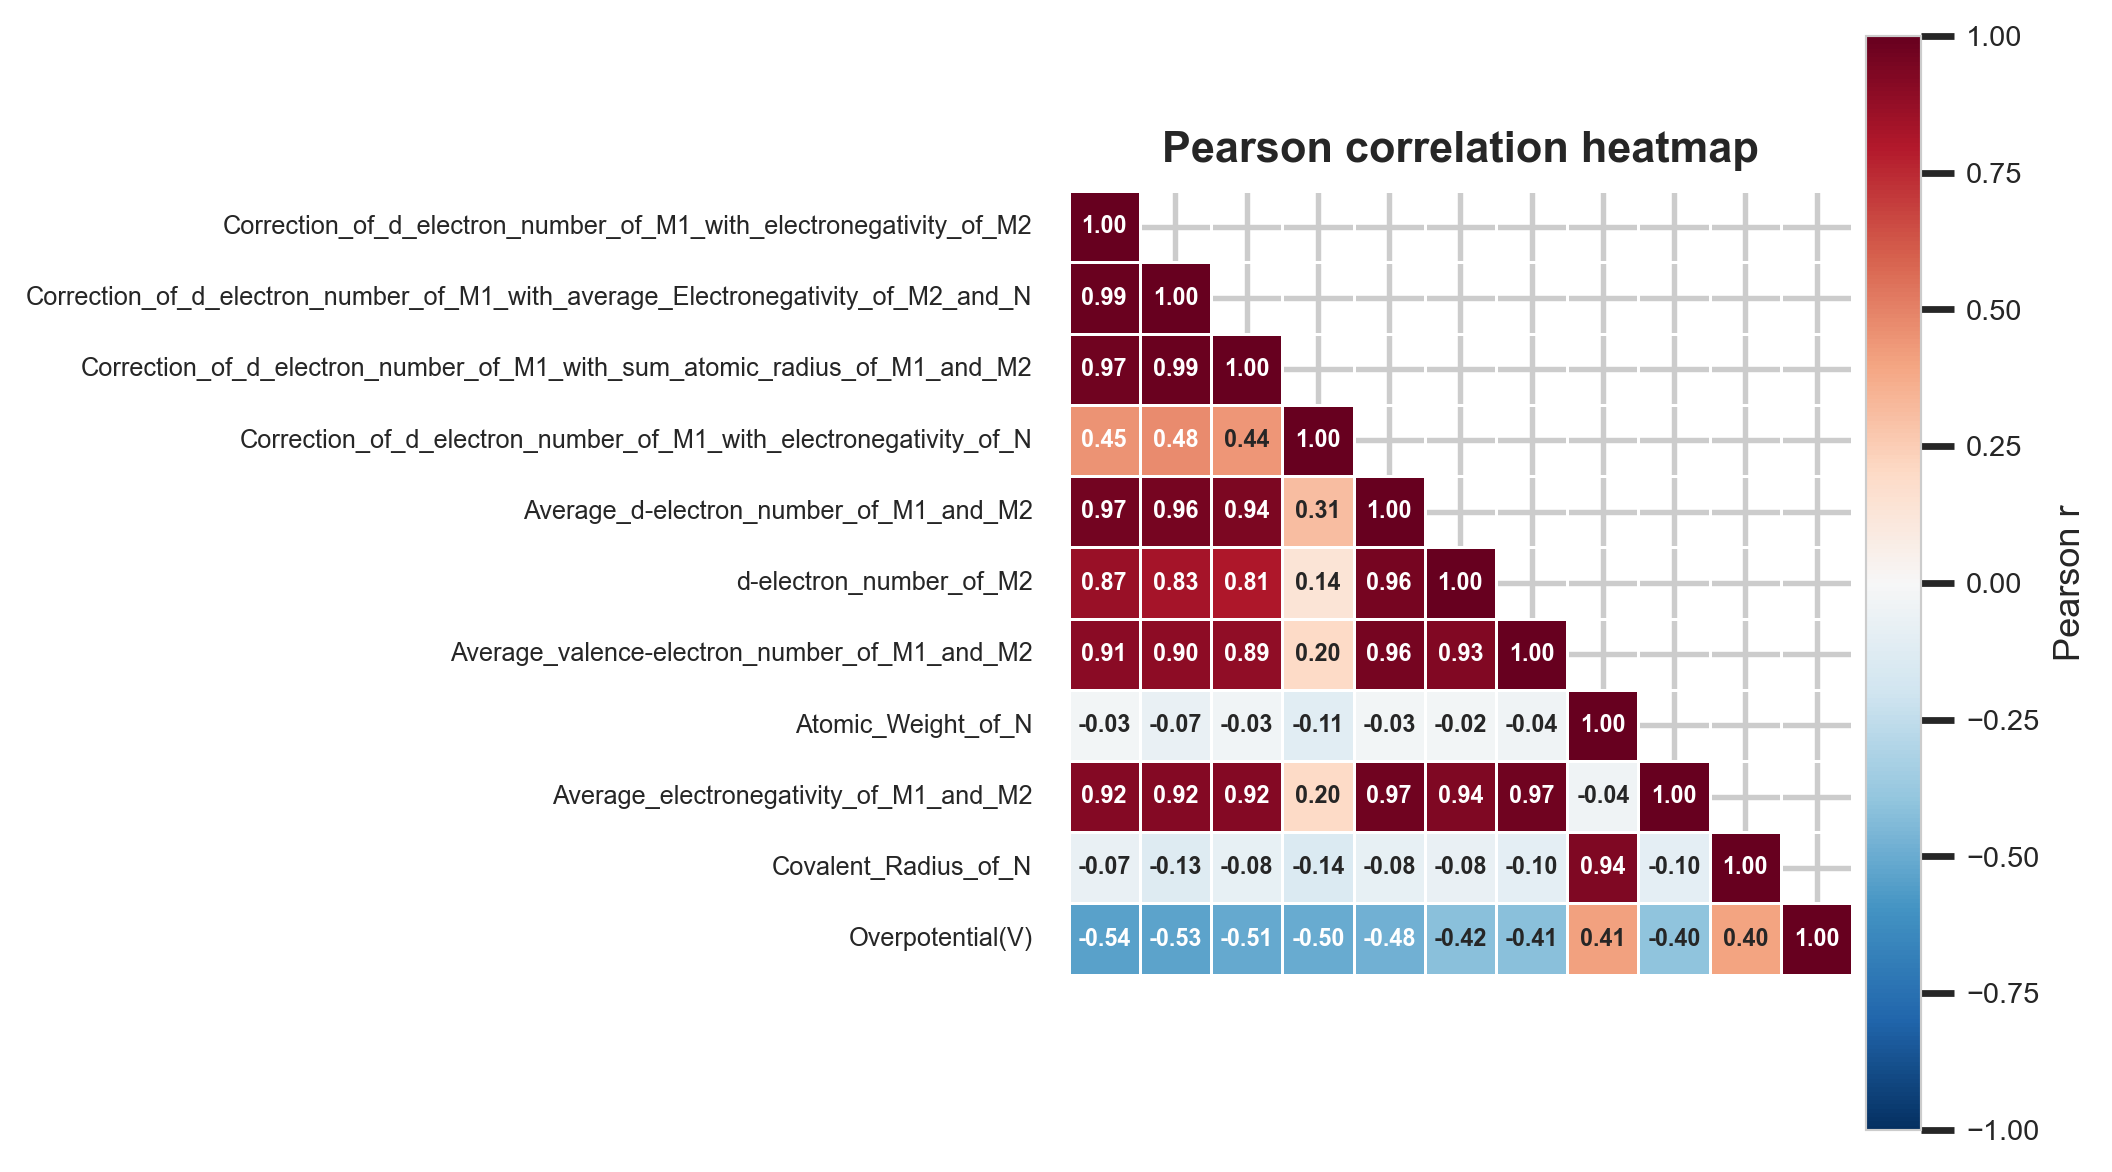

In [8]:

# 1) Pearson 相关性测试：物理特征 vs 过电位
pearson_rows = []
y_series = pd.Series(y, name='Overpotential(V)')
for col in physical_cols:
    x_col = pd.to_numeric(X[col], errors='coerce').fillna(0)
    r, p = pearsonr(x_col.values, y_series.values)
    pearson_rows.append({'feature': col, 'pearson_r': float(r), 'p_value': float(p), 'abs_r': float(abs(r))})

pearson_df = pd.DataFrame(pearson_rows).sort_values('abs_r', ascending=False).reset_index(drop=True)
pearson_df.to_csv(OUT_DIR / 'pearson_physical_vs_target.csv', index=False, encoding='utf-8-sig')
print(pearson_df.head(10))

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 9,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

fig, ax = plt.subplots(figsize=(7.6, 6.2), dpi=260)
top_n = min(10, len(pearson_df))
heatmap_features = pearson_df.head(top_n)['feature'].tolist()
heatmap_df = pd.concat(
    [X[heatmap_features].apply(pd.to_numeric, errors='coerce').fillna(0), y_series],
    axis=1,
)
corr_mat = heatmap_df.corr(method='pearson')

corr_mat.to_csv(OUT_DIR / 'pearson_heatmap_matrix.csv', encoding='utf-8-sig')

mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
heat = sns.heatmap(
    corr_mat,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.35,
    linecolor='white',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 6.5, 'weight': 'bold'},
    cbar_kws={'shrink': 0.72, 'pad': 0.015, 'label': 'Pearson r'},
    ax=ax,
)

ax.set_title('Pearson correlation heatmap', pad=8, weight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', bottom=False, labelbottom=False)
ax.tick_params(axis='y', labelrotation=0, pad=1)

for label in ax.get_yticklabels():
    label.set_fontsize(7)

cbar = heat.collections[0].colorbar
cbar.outline.set_linewidth(0.6)
cbar.ax.tick_params(labelsize=8)

fig.tight_layout(pad=0.5)
fig.savefig(OUT_DIR / 'pearson_heatmap_publication.png', dpi=320, bbox_inches='tight')
fig.savefig(OUT_DIR / 'pearson_heatmap_publication.pdf', bbox_inches='tight')
plt.show()

# 4. 8 ml models training and hyper-parameters tuning
  1. XGBoost
  2. GradientBoosting
  3. RandomForest
  4. ExtraTrees
  5. SVM (RBF)
  6. ElasticNet
  7. Lasso
  8. Ridge

In [9]:
model_specs = {
    'elasticnet': (
        Pipeline([('scaler', StandardScaler()), ('reg', ElasticNet(max_iter=20000, random_state=RANDOM_STATE))]),
        {'reg__alpha': [0.01, 0.1, 1.0], 'reg__l1_ratio': [0.2, 0.5, 0.8]}
    ),
    'extratrees': (
        ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {'n_estimators': [300, 500], 'max_depth': [None, 10], 'min_samples_split': [2, 5]}
    ),
    'gradientboosting': (
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {'n_estimators': [200, 400], 'learning_rate': [0.03, 0.05], 'max_depth': [2, 3]}
    ),
    'lasso': (
        Pipeline([('scaler', StandardScaler()), ('reg', Lasso(max_iter=20000, random_state=RANDOM_STATE))]),
        {'reg__alpha': [0.001, 0.01, 0.1]}
    ),
    'rf': (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {'n_estimators': [300, 500], 'max_depth': [None, 10], 'min_samples_split': [2, 5]}
    ),
    'ridge': (
        Pipeline([('scaler', StandardScaler()), ('reg', Ridge(random_state=RANDOM_STATE))]),
        {'reg__alpha': [0.1, 1.0, 10.0]}
    ),
    'svm': (
        Pipeline([('scaler', StandardScaler()), ('reg', SVR(kernel='rbf'))]),
        {'reg__C': [1, 10], 'reg__gamma': ['scale', 0.05], 'reg__epsilon': [0.05, 0.1]}
    ),
    'xgboost': (
        xgb.XGBRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
            objective='reg:squarederror'
        ),
        {'n_estimators': [200, 400], 'max_depth': [3, 5], 'learning_rate': [0.03, 0.05], 'subsample': [0.8, 1.0]}
    )
}

tuning_outputs = {}
rows = []
for name, (estimator, grid) in model_specs.items():
    print(f'==== tuning {name} ====')
    out = tune_one_model(name, estimator, grid, X, y, groups, seed=RANDOM_STATE)
    tuning_outputs[name] = out
    rows.append({
        'model': name,
        'cv_mean_r2': out['cv_mean_r2'],
        'cv_std_r2': out['cv_std_r2'],
        'grid_best_score': out['grid_best_score'],
        'best_params': json.dumps(out['best_params'], ensure_ascii=False)
    })
    print('best params:', out['best_params'])
    print(f'cv_mean_r2: {out["cv_mean_r2"]:.4f} ± {out["cv_std_r2"]:.4f}')

model_results = pd.DataFrame(rows).sort_values('cv_mean_r2', ascending=False).reset_index(drop=True)
model_results.to_csv(OUT_DIR / 'model_comparison.csv', index=False, encoding='utf-8-sig')
display(model_results)

best_model_name = model_results.loc[0, 'model']
best_model_output = tuning_outputs[best_model_name]
print('Best model =', best_model_name)

==== tuning elasticnet ====
best params: {'reg__alpha': 0.01, 'reg__l1_ratio': 0.8}
cv_mean_r2: 0.6577 ± 0.0622
==== tuning extratrees ====
best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 500}
cv_mean_r2: 0.8385 ± 0.0450
==== tuning gradientboosting ====
best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 400}
cv_mean_r2: 0.8779 ± 0.0292
==== tuning lasso ====
best params: {'reg__alpha': 0.01}
cv_mean_r2: 0.6502 ± 0.0616
==== tuning rf ====
best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 500}
cv_mean_r2: 0.8698 ± 0.0337
==== tuning ridge ====
best params: {'reg__alpha': 10.0}
cv_mean_r2: 0.4740 ± 0.3500
==== tuning svm ====
best params: {'reg__C': 1, 'reg__epsilon': 0.05, 'reg__gamma': 'scale'}
cv_mean_r2: 0.7490 ± 0.0674
==== tuning xgboost ====
best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.8}
cv_mean_r2: 0.8815 ± 0.0346


,model,cv_mean_r2,cv_std_r2,grid_best_score,best_params
0,xgboost,0.881496,0.034579,0.880552,"{""learning_rate"": 0.05, ""max_depth"": 3, ""n_est..."
1,gradientboosting,0.877913,0.029218,0.877913,"{""learning_rate"": 0.05, ""max_depth"": 3, ""n_est..."
2,rf,0.869781,0.033664,0.869781,"{""max_depth"": 10, ""min_samples_split"": 2, ""n_e..."
3,extratrees,0.838533,0.044961,0.838533,"{""max_depth"": 10, ""min_samples_split"": 5, ""n_e..."
4,svm,0.749015,0.067448,0.749015,"{""reg__C"": 1, ""reg__epsilon"": 0.05, ""reg__gamm..."
5,elasticnet,0.657695,0.062215,0.657695,"{""reg__alpha"": 0.01, ""reg__l1_ratio"": 0.8}"
6,lasso,0.650179,0.061550,0.650179,"{""reg__alpha"": 0.01}"
7,ridge,0.473979,0.350021,0.473979,"{""reg__alpha"": 10.0}"


Best model = xgboost


Saved to: results\analysis\all_models_parity_predictions.csv


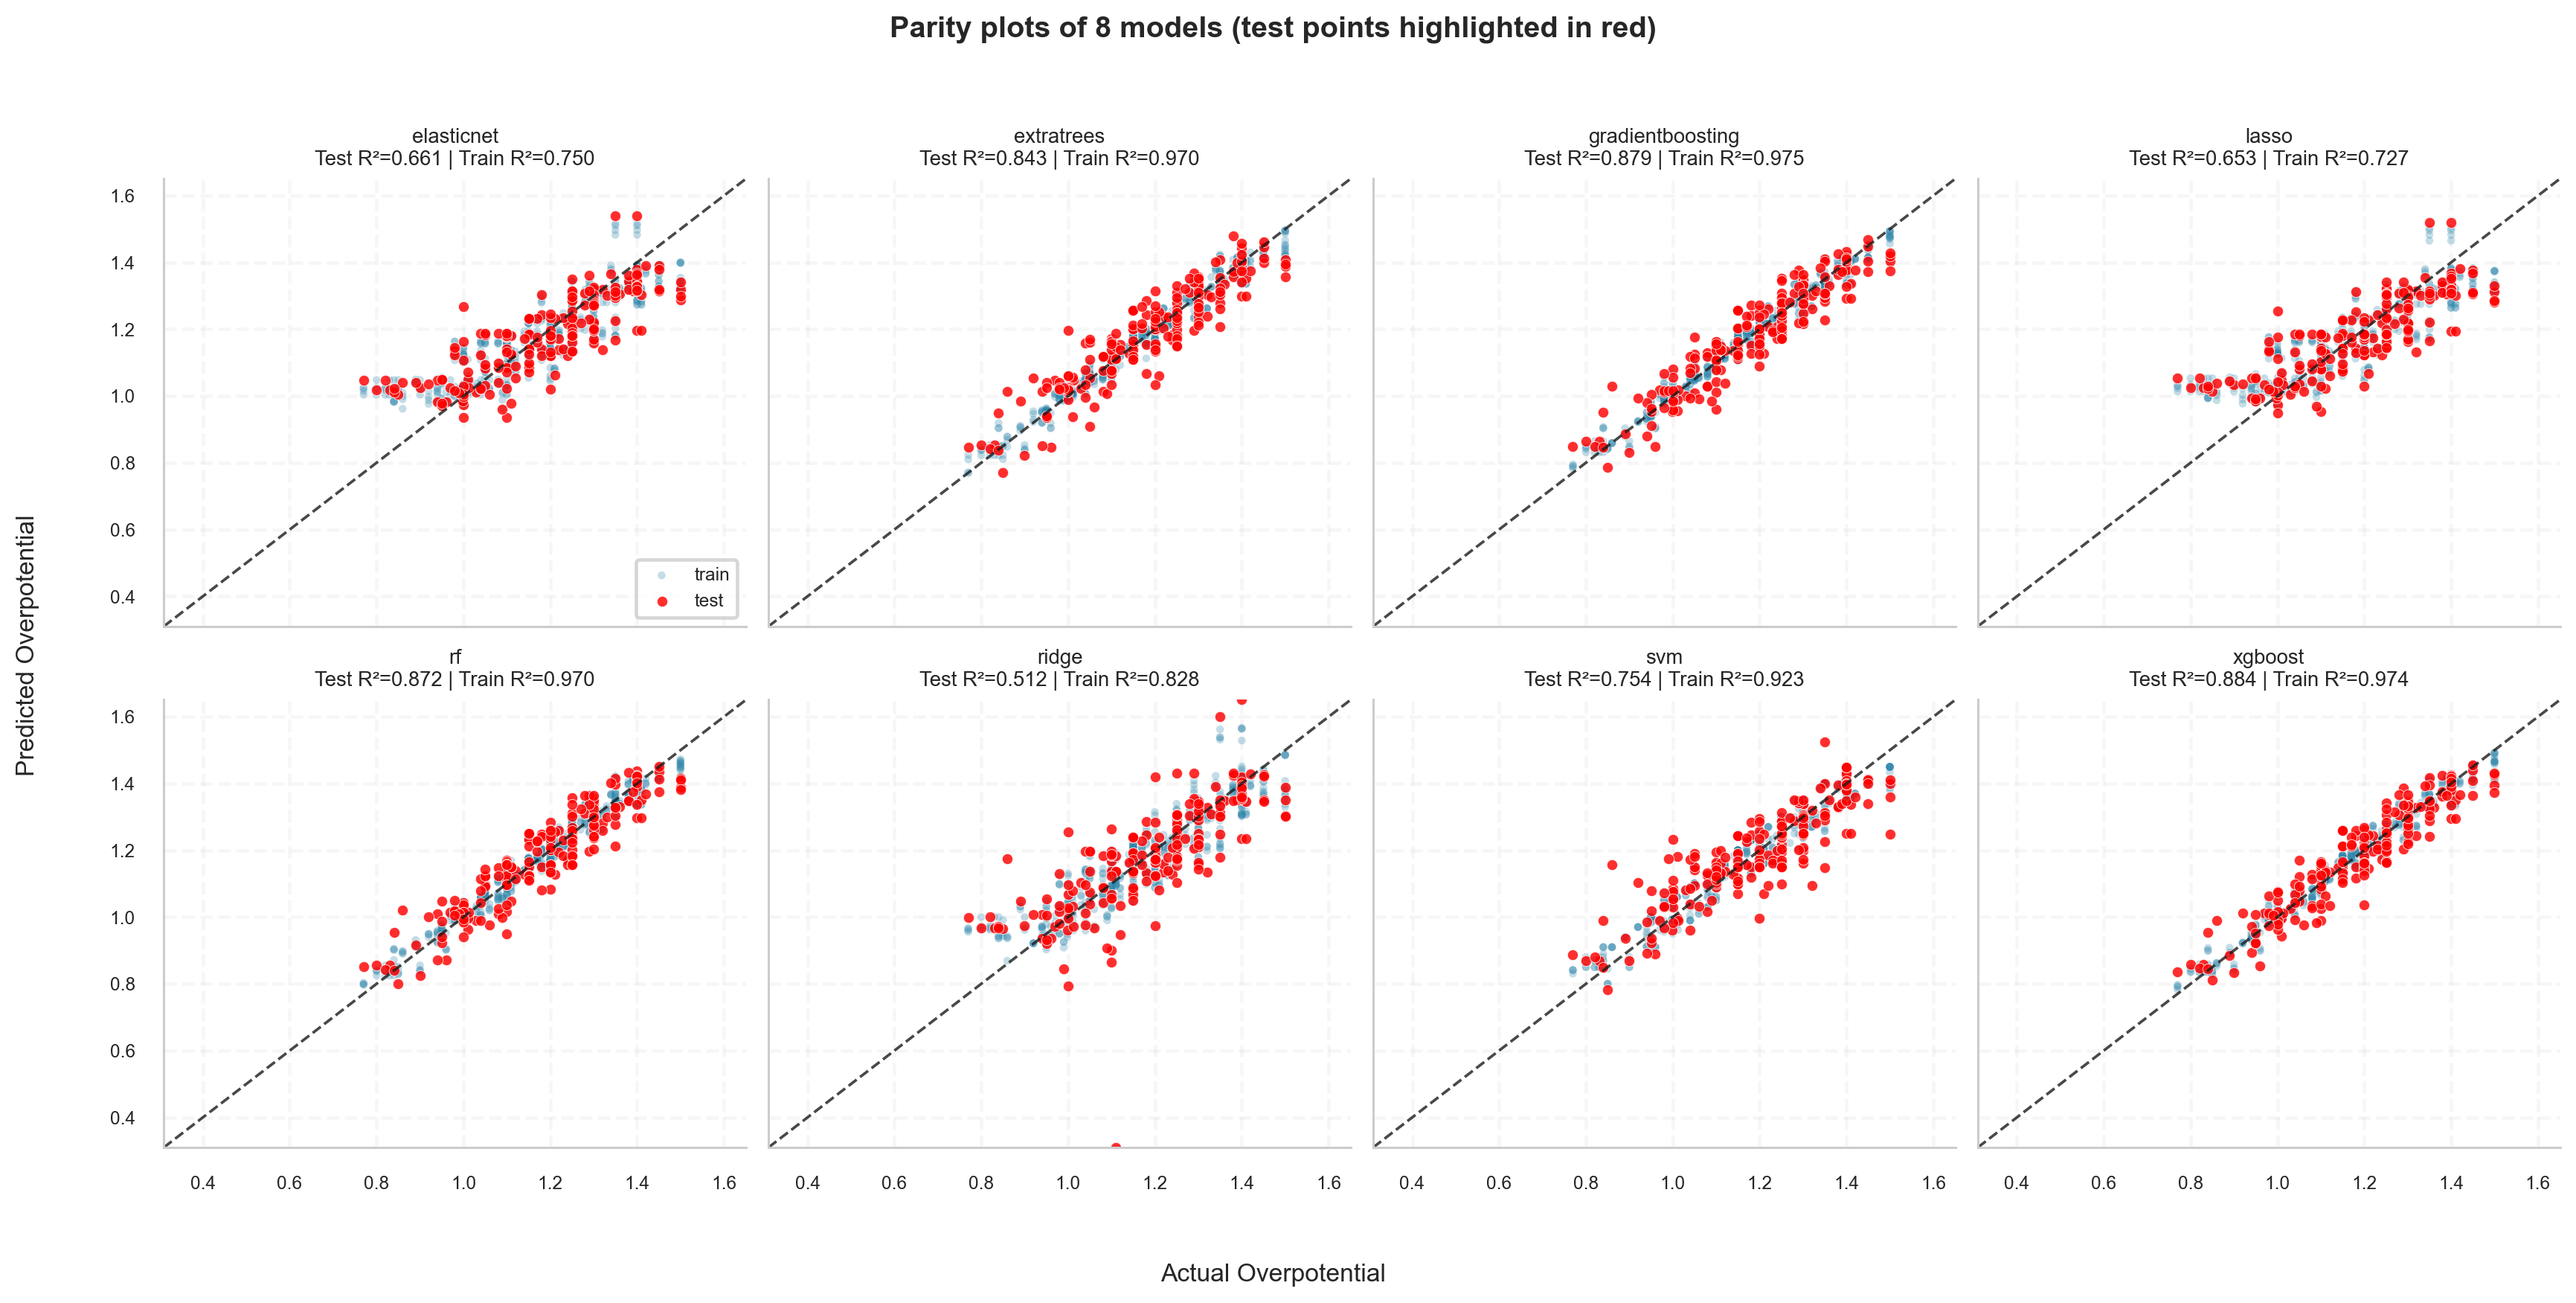

,model,train_r2,test_r2,oof_r2,cv_mean_r2,cv_std_r2
0,xgboost,0.974444,0.884089,0.884089,0.881496,0.034579
1,gradientboosting,0.975015,0.879400,0.879400,0.877913,0.029218
2,rf,0.970017,0.871581,0.871581,0.869781,0.033664
3,extratrees,0.970120,0.843238,0.843238,0.838533,0.044961
4,svm,0.923340,0.753952,0.753952,0.749015,0.067448
5,elasticnet,0.749524,0.661075,0.661075,0.657695,0.062215
6,lasso,0.727061,0.652583,0.652583,0.650179,0.061550
7,ridge,0.828209,0.511997,0.511997,0.473979,0.350021


Best model by TEST R²: xgboost, R²=0.8841


In [10]:
# Parity plot
all_pred_rows = []
for model_name, out in tuning_outputs.items():
    cv_df = out['cv_pred_df'].copy()
    if len(cv_df) == 0:
        continue
    cv_df['model'] = model_name
    all_pred_rows.append(cv_df)

all_pred_df = pd.concat(all_pred_rows, ignore_index=True)
all_pred_df.to_csv(OUT_DIR / 'all_models_parity_predictions.csv', index=False, encoding='utf-8-sig')
print("Saved to:", OUT_DIR / 'all_models_parity_predictions.csv')

min_v = float(min(all_pred_df['y_true'].min(), all_pred_df['y_pred'].min()))
max_v = float(max(all_pred_df['y_true'].max(), all_pred_df['y_pred'].max()))


model_names = list(tuning_outputs.keys())
fig, axes = plt.subplots(2, 4, figsize=(16, 8), dpi=220, sharex=True, sharey=True)
axes = axes.ravel()

for idx, (ax, model_name) in enumerate(zip(axes, model_names)):
    mdf = all_pred_df[all_pred_df['model'] == model_name].copy()
    tr_df = mdf[mdf['set_type'] == 'train']
    te_df = mdf[mdf['set_type'] == 'test']

    train_r2 = float(r2_score(tr_df['y_true'], tr_df['y_pred'])) if len(tr_df) > 1 else np.nan
    test_r2 = float(r2_score(te_df['y_true'], te_df['y_pred'])) if len(te_df) > 1 else np.nan

    if len(tr_df) > 0:
        ax.scatter(
            tr_df['y_true'],
            tr_df['y_pred'],
            s=12,
            alpha=0.28,
            color='#2E86AB',
            edgecolor='none',
            label='train' if idx == 0 else None,
        )
    if len(te_df) > 0:
        ax.scatter(
            te_df['y_true'],
            te_df['y_pred'],
            s=22,
            alpha=0.82,
            color='red',
            edgecolor='white',
            linewidth=0.3,
            label='test' if idx == 0 else None,
        )

    ax.plot([min_v, max_v], [min_v, max_v], 'k--', linewidth=1.2, alpha=0.8)
    ax.set_xlim(min_v, max_v)
    ax.set_ylim(min_v, max_v)
    ax.set_title(f"{model_name}\nTest R²={test_r2:.3f} | Train R²={train_r2:.3f}", fontsize=9, pad=6)
    ax.grid(alpha=0.16, linestyle='--')
    ax.tick_params(labelsize=8)

for ax in axes[len(model_names):]:
    ax.axis('off')

if len(model_names) > 0:
    axes[0].legend(loc='lower right', fontsize=8, frameon=True)

fig.supxlabel('Actual Overpotential', fontsize=11)
fig.supylabel('Predicted Overpotential', fontsize=11)
fig.suptitle('Parity plots of 8 models (test points highlighted in red)', fontsize=13, weight='bold', y=0.98)
fig.tight_layout(rect=[0.03, 0.03, 1, 0.95])
fig.savefig(OUT_DIR / 'parity_plot_all_models_subplots.png', dpi=300, bbox_inches='tight')
fig.savefig(OUT_DIR / 'parity_plot_all_models_subplots.pdf', bbox_inches='tight')
plt.show()

summary_rows = []
for model_name in model_names:
    mdf = all_pred_df[all_pred_df['model'] == model_name]
    tr_df = mdf[mdf['set_type'] == 'train']
    te_df = mdf[mdf['set_type'] == 'test']
    summary_rows.append({
        'model': model_name,
        'train_r2': float(r2_score(tr_df['y_true'], tr_df['y_pred'])) if len(tr_df) > 1 else np.nan,
        'test_r2': float(r2_score(te_df['y_true'], te_df['y_pred'])) if len(te_df) > 1 else np.nan,
        'oof_r2': float(r2_score(te_df['y_true'], te_df['y_pred'])) if len(te_df) > 1 else np.nan,
        'cv_mean_r2': float(tuning_outputs[model_name]['cv_mean_r2']),
        'cv_std_r2': float(tuning_outputs[model_name]['cv_std_r2']),
    })
model_oof_summary = pd.DataFrame(summary_rows).sort_values('test_r2', ascending=False).reset_index(drop=True)
model_oof_summary.to_csv(OUT_DIR / 'all_models_oof_r2_summary.csv', index=False, encoding='utf-8-sig')
display(model_oof_summary)


best_model_name = model_oof_summary.loc[0, 'model']
best_model_output = tuning_outputs[best_model_name]
r2_oof = float(model_oof_summary.loc[model_oof_summary['model'] == best_model_name, 'test_r2'].iloc[0])
print(f'Best model by TEST R²: {best_model_name}, R²={r2_oof:.4f}')

seed=00, mean R²=0.8531, std=0.0357
seed=01, mean R²=0.8604, std=0.0391
seed=02, mean R²=0.8591, std=0.0424
seed=03, mean R²=0.8682, std=0.0309
seed=04, mean R²=0.8710, std=0.0313
seed=05, mean R²=0.8599, std=0.0246
seed=06, mean R²=0.8786, std=0.0202
seed=07, mean R²=0.8647, std=0.0322
seed=08, mean R²=0.8626, std=0.0427
seed=09, mean R²=0.8631, std=0.0377


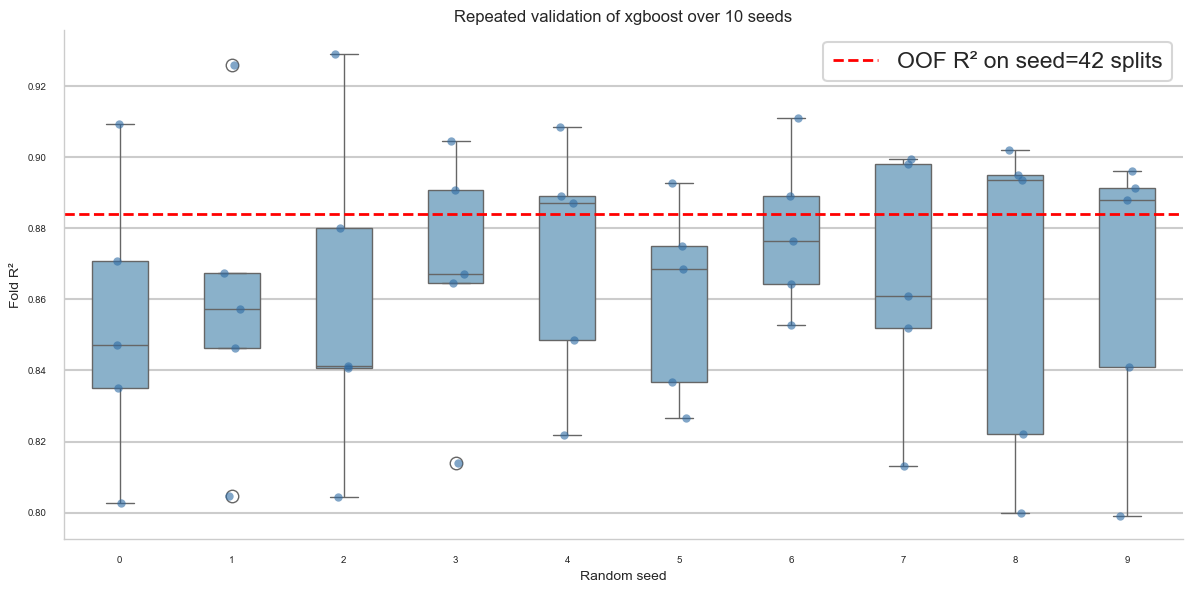

,seed,mean,std
0,0,0.853079,0.039941
1,1,0.860354,0.043681
2,2,0.859097,0.047452
3,3,0.868180,0.034570
4,4,0.871018,0.035045
5,5,0.859862,0.027510
6,6,0.878646,0.022558
7,7,0.864687,0.035960
8,8,0.862567,0.047756
9,9,0.863071,0.042111


In [11]:
# Repeated validation with 10 different random seeds
repeat_rows = []
for seed in range(N_REPEAT_SEEDS):
    splits = make_group_splits(groups, n_splits=N_SPLITS, seed=seed)
    fold_scores, _, _ = evaluate_estimator(best_model_output['best_estimator'], X, y, splits)
    for fold_idx, score in enumerate(fold_scores):
        repeat_rows.append({'seed': seed, 'fold': fold_idx, 'r2': float(score)})
    print(f'seed={seed:02d}, mean R²={np.mean(fold_scores):.4f}, std={np.std(fold_scores):.4f}')

repeat_df = pd.DataFrame(repeat_rows)
repeat_df.to_csv(OUT_DIR / 'repeat_validation_folds.csv', index=False, encoding='utf-8-sig')

boxplot_stats = repeat_df.groupby('seed')['r2'].describe(percentiles=[0.25, 0.5, 0.75])
boxplot_stats.to_csv(OUT_DIR / 'repeat_validation_boxplot_stats.csv', encoding='utf-8-sig')

plt.figure(figsize=(12, 6))
sns.boxplot(data=repeat_df, x='seed', y='r2', color='#7FB3D5', width=0.5)
sns.stripplot(data=repeat_df, x='seed', y='r2', color='#2E6BA4', size=6, alpha=0.6, jitter=0.08)
plt.axhline(r2_oof, color='red', linestyle='--', linewidth=2, label='OOF R² on seed=42 splits')
plt.xlabel('Random seed')
plt.ylabel('Fold R²')
plt.title(f'Repeated validation of {best_model_name} over 10 seeds')
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'repeat_validation_boxplot.png', dpi=180, bbox_inches='tight')
plt.show()

repeat_summary = repeat_df.groupby('seed')['r2'].agg(['mean', 'std']).reset_index()
repeat_summary.to_csv(OUT_DIR / 'repeat_validation_summary.csv', index=False, encoding='utf-8-sig')
display(repeat_summary)

# 5. SHAP analysis

TreeExplainer failed: could not convert string to float: '[1.18485E0]', fallback to xgboost pred_contribs
Top 15 total features:
                                              feature  mean_abs_shap
46  Correction_of_d_electron_number_of_M1_with_ele...       0.087901
47  Correction_of_d_electron_number_of_M1_with_ave...       0.031024
49                                d-band_center_of_M1       0.028674
48  Correction_of_d_electron_number_of_M1_with_sum...       0.026220
6                                  Atomic_Weight_of_N       0.012572
42              Average_electronegativity_of_M1_and_N       0.012377
1                    Limited_specific_capacity(mAh/g)       0.011508
0                               Current_density(mA/g)       0.010427
2                             Current_density(mA/g).1       0.009003
3                  Limited_specific_capacity(mAh/g).1       0.006280
45  Correction_of_d_electron_number_of_M1_with_ele...       0.003422
17                            Electron_Affi

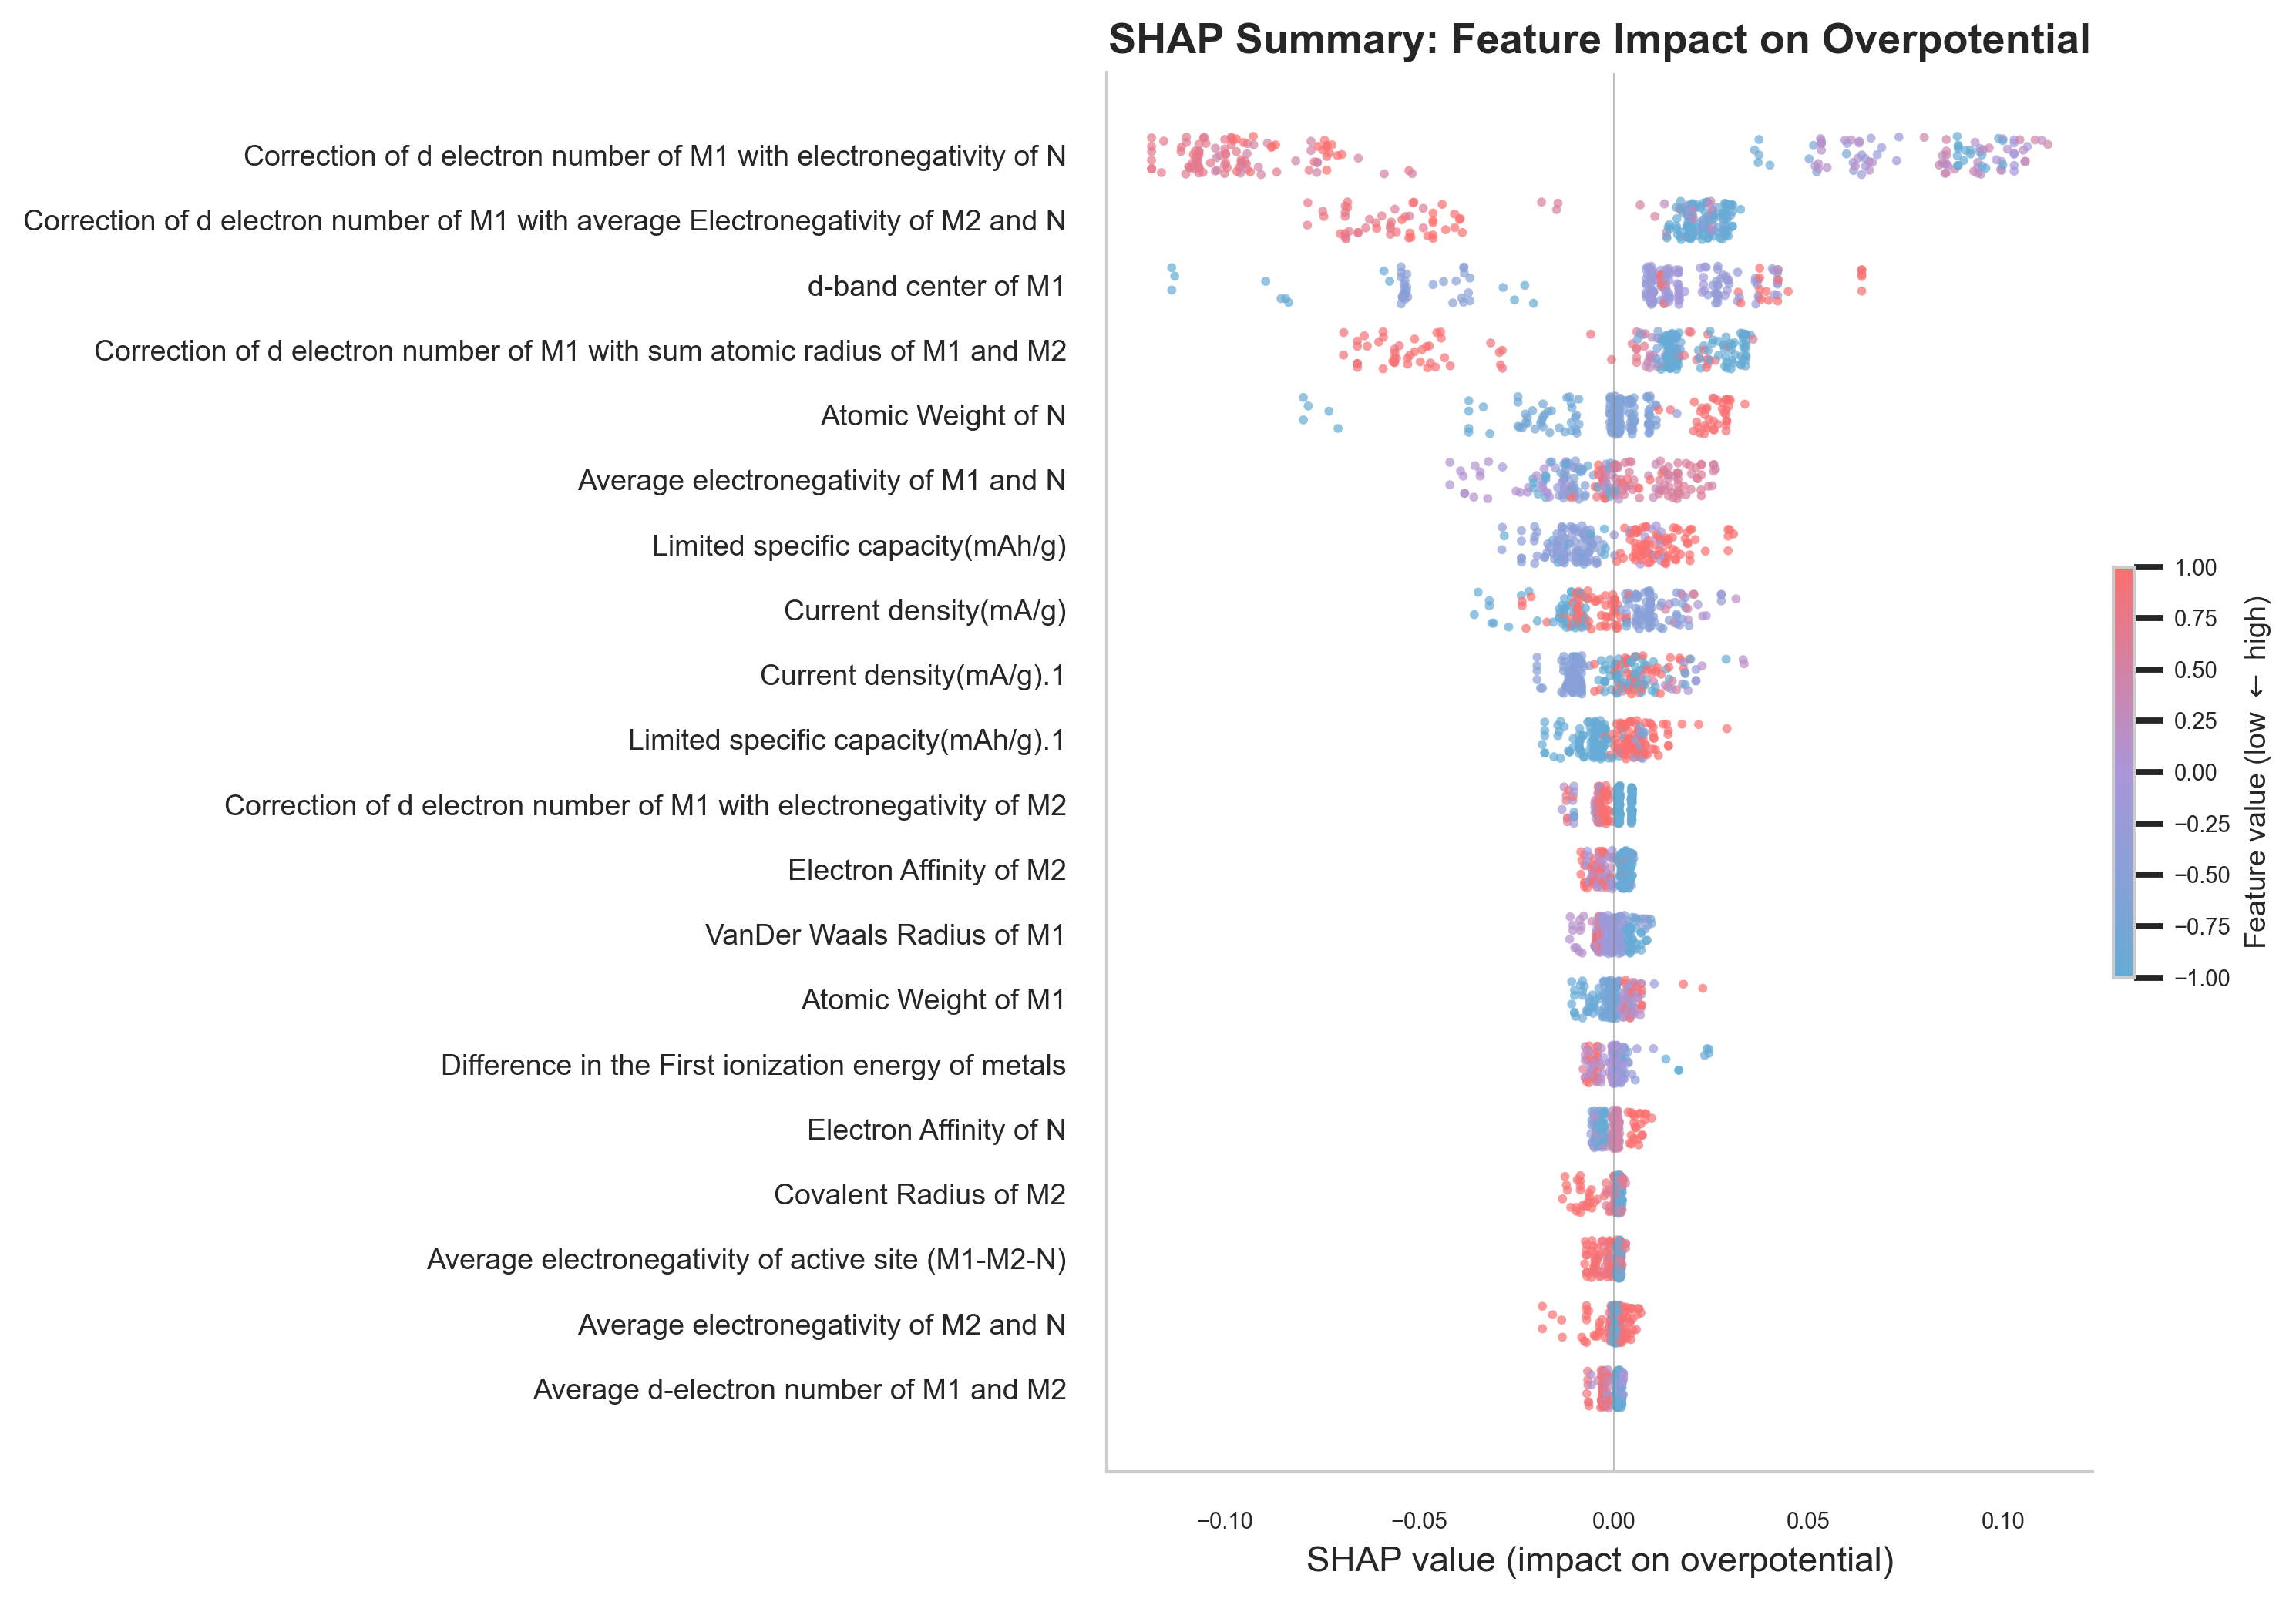


SHAP analysis complete. Saved beeswarm and model to: results\analysis
- SHAP total importance: shap_total_importance.csv
- SHAP physical importance: shap_physical_importance.csv
- SHAP element importance: shap_element_importance.csv
- SHAP beeswarm plot: shap_beeswarm_publication.png/pdf
- Analysis summary: analysis_summary.json
- Final model: final_model_xgboost.joblib


In [12]:
# SHAP analysis for the best model
import shap
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import joblib
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path


shap_model = tuning_outputs['xgboost']['best_estimator']

X_shap = X.apply(pd.to_numeric, errors='coerce').fillna(0.0).astype(np.float32)

try:
    explainer = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(X_shap)
    expected_value = explainer.expected_value
except Exception as e:
    print(f'TreeExplainer failed: {e}, fallback to xgboost pred_contribs')
    booster = shap_model.get_booster()
    dmat = xgb.DMatrix(X_shap, feature_names=list(X_shap.columns))
    contrib = booster.predict(dmat, pred_contribs=True)
    shap_values = contrib[:, :-1]
    expected_value = float(np.mean(contrib[:, -1]))

if isinstance(shap_values, list):
    shap_values = shap_values[0]

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_total_df = pd.DataFrame({'feature': X_shap.columns, 'mean_abs_shap': mean_abs_shap}).sort_values('mean_abs_shap', ascending=False)
shap_total_df.to_csv(OUT_DIR / 'shap_total_importance.csv', index=False, encoding='utf-8-sig')

shap_physical_df = shap_total_df[shap_total_df['feature'].isin(physical_cols)].sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
shap_elements_df = shap_total_df[shap_total_df['feature'].isin(element_cols)].sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
shap_physical_df.to_csv(OUT_DIR / 'shap_physical_importance.csv', index=False, encoding='utf-8-sig')
shap_elements_df.to_csv(OUT_DIR / 'shap_element_importance.csv', index=False, encoding='utf-8-sig')

print('Top 15 total features:')
print(shap_total_df.head(15))
print('\nTop 10 physical features:')
print(shap_physical_df.head(10))
print('\nTop 10 element features:')
print(shap_elements_df.head(10))

colors_custom = ['#66ABD5', '#AA96DA', '#FB6F6F']  
custom_cmap = LinearSegmentedColormap.from_list('custom_blue_purple_red', colors_custom, N=256)

fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
top_n = 20
top_features = shap_total_df.head(top_n)['feature'].tolist()

for i, feat in enumerate(reversed(top_features)):
    feat_idx = list(X_shap.columns).index(feat)
    sv = shap_values[:, feat_idx]
    fv = X_shap[feat].values
    order = np.argsort(sv)
    sv_sorted = sv[order]
    fv_sorted = fv[order]
    rng = np.random.RandomState(42)
    jitter = rng.uniform(-0.3, 0.3, len(sv_sorted))
    y_pos = np.full(len(sv_sorted), i) + jitter
    low = np.nanpercentile(fv_sorted, 5)
    high = np.nanpercentile(fv_sorted, 95)
    norm = plt.Normalize(low, high) if high > low else plt.Normalize(-1, 1)
    colors = custom_cmap(norm(fv_sorted))
    ax.scatter(sv_sorted, y_pos, c=colors, s=8, alpha=0.7, edgecolors='none', rasterized=True)

ax.set_yticks(range(len(top_features)))
ax.set_yticklabels([f.replace('_', ' ') for f in reversed(top_features)], fontsize=9)
ax.set_xlabel('SHAP value (impact on overpotential)', fontsize=11)
ax.set_title('SHAP Summary: Feature Impact on Overpotential', fontsize=13, weight='bold')
ax.axvline(0, color='grey', linestyle='-', linewidth=0.5, alpha=0.5)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(-1, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label(r'Feature value (low $\leftarrow$ high)', fontsize=9)
cbar.ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig(OUT_DIR / 'shap_beeswarm_publication.png', dpi=350, bbox_inches='tight')
plt.savefig(OUT_DIR / 'shap_beeswarm_publication.pdf', bbox_inches='tight')
plt.show()

summary = {
    'best_model': best_model_name,
    'best_model_oof_r2': float(r2_oof),
    'n_samples': int(len(df)),
    'n_features': int(X.shape[1])
}
with open(OUT_DIR / 'analysis_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

joblib.dump(best_model_output['best_estimator'], OUT_DIR / f'final_model_{best_model_name}.joblib')
print(f'\nSHAP analysis complete. Saved beeswarm and model to: {OUT_DIR}')
print(f'- SHAP total importance: shap_total_importance.csv')
print(f'- SHAP physical importance: shap_physical_importance.csv')
print(f'- SHAP element importance: shap_element_importance.csv')
print(f'- SHAP beeswarm plot: shap_beeswarm_publication.png/pdf')
print(f'- Analysis summary: analysis_summary.json')
print(f'- Final model: final_model_{best_model_name}.joblib')

# 6. Dataset overview

In [13]:
# ==========================================================
# [TASK A] 3x2 Comprehensive Dataset Overview
# ==========================================================
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import spearmanr
from matplotlib.colors import LinearSegmentedColormap

# Data preparation
df_ov = pd.read_csv(DATA_PATH)

def extract_elements(comp_str):
    if pd.isna(comp_str):
        return []
    s = str(comp_str).strip()
    if s == '':
        return []
    tokens = [t.strip() for t in s.replace(' ', '').split('-')]
    # 保留可识别元素，只过滤占位符 **
    return [t for t in tokens if t and t != '**']

df_ov['Elements'] = df_ov['Compounds(M1-M2-N)'].apply(extract_elements)

# Targets
y_ov = pd.to_numeric(df_ov['Overpotential(V)'], errors='coerce')
y_cp = pd.to_numeric(df_ov['Cycling_performance'], errors='coerce') if 'Cycling_performance' in df_ov.columns else None

# Feature matrix (physical features only)
ov_exclude = ['data_source', 'Compounds(M1-M2-N)', 'Original_Compounds', 'Overpotential(V)',
              'Cycling_performance', 'cycling_performance', 'Elements']
ov_phys = [c for c in df_ov.columns if c not in ov_exclude]
X_ov = df_ov[ov_phys].apply(pd.to_numeric, errors='coerce').fillna(0)

# Elements
all_el = [e for sub in df_ov['Elements'] for e in sub]
el_counts = pd.Series(all_el).value_counts()
unique_els = el_counts.index.tolist()

METALS = set(['Li','Be','Na','Mg','Al','K','Ca','Sc','Ti','V','Cr','Mn','Fe','Co','Ni','Cu','Zn',
              'Ga','Ge','Rb','Sr','Y','Zr','Nb','Mo','Tc','Ru','Rh','Pd','Ag','Cd','In','Sn','Cs',
              'Ba','La','Hf','Ta','W','Re','Os','Ir','Pt','Au','Hg','Tl','Pb','Bi','Fr','Ra','Ac',
              'Th','Pa','U','Np','Pu'])
metals_in = [e for e in unique_els if e in METALS]
elems = metals_in if len(metals_in) >= 2 else unique_els

# Co-occurrence
n = len(elems)
idx_map = {e:i for i,e in enumerate(elems)}
co = np.zeros((n,n), dtype=int)
for lst in df_ov['Elements']:
    inds = [idx_map[e] for e in lst if e in idx_map]
    for i in range(len(inds)):
        for j in range(i+1, len(inds)):
            a, b = inds[i], inds[j]
            co[a,b] += 1; co[b,a] += 1

# Element groups
def classify_group(lst):
    return '-'.join(sorted(set(lst))) if lst else 'Unknown'
df_ov['ElementGroup'] = df_ov['Elements'].apply(classify_group)
elem_grp = df_ov['ElementGroup'].value_counts()

# t-SNE
scaler = StandardScaler()
X_ov_norm = scaler.fit_transform(X_ov)
perp = max(5, min(30, (X_ov_norm.shape[0] - 1) // 3))
try:
    tsne = TSNE(n_components=2, perplexity=perp, learning_rate='auto', init='pca', random_state=42)
    X_ov_2d = tsne.fit_transform(X_ov_norm)
    print(f't-SNE: perplexity={perp}')
except Exception as e:
    print(f't-SNE failed: {e}; fallback to PCA(2)')
    X_ov_2d = PCA(n_components=2, random_state=42).fit_transform(X_ov_norm)

# Correlation
corr_df_all = X_ov.copy()
corr_df_all['Overpotential(V)'] = y_ov.fillna(y_ov.median()).values
corr_mat = corr_df_all.corr()
cmap_bp = LinearSegmentedColormap.from_list('bp', [PRIMARY, '#F5F5F5', PINK], N=100)

print(f'Overview: {len(df_ov)} samples, {X_ov.shape[1]} features, {len(elems)} elements')
print(f'Top elements: {el_counts.head(8).to_dict()}')
print(f'Top groups: {elem_grp.head(8).to_dict()}')


X_ov.to_csv(OUT_DIR / 'physical_features.csv', index=False, encoding='utf-8-sig')

target_df = pd.DataFrame({'Overpotential(V)': y_ov})
if y_cp is not None:
    target_df['Cycling_performance'] = y_cp
target_df.to_csv(OUT_DIR / 'target_values.csv', index=False, encoding='utf-8-sig')

df_ov[['Compounds(M1-M2-N)', 'ElementGroup']].to_csv(OUT_DIR / 'element_groups.csv', index=False, encoding='utf-8-sig')

co_df = pd.DataFrame(co, index=elems, columns=elems)
co_df.to_csv(OUT_DIR / 'element_cooccurrence.csv', encoding='utf-8-sig')

tsne_df = pd.DataFrame({'tSNE_1': X_ov_2d[:, 0], 'tSNE_2': X_ov_2d[:, 1], 'Overpotential(V)': y_ov.values})
tsne_df.to_csv(OUT_DIR / 'tsne_embedding.csv', index=False, encoding='utf-8-sig')

sp_rows = []
y_full = y_ov.fillna(y_ov.median())
for col in ov_phys:
    xv = pd.to_numeric(X_ov[col], errors='coerce').fillna(0)
    try:
        r, p = spearmanr(xv, y_full)
    except:
        r, p = 0, 1
    sp_rows.append({'feature': col, 'spearman_rho': r, 'p_value': p, 'abs_rho': abs(r)})
sp_df = pd.DataFrame(sp_rows).sort_values('abs_rho', ascending=False).reset_index(drop=True)
sp_df.to_csv(OUT_DIR / 'spearman_correlations.csv', index=False, encoding='utf-8-sig')
print('Saved CSVs to:', OUT_DIR)

t-SNE failed: 'NoneType' object has no attribute 'split'; fallback to PCA(2)
Overview: 200 samples, 51 features, 18 elements
Top elements: {'O': 116, 'Co': 80, 'Ni': 53, 'Fe': 36, 'N': 34, 'Ru': 29, 'S': 21, 'Mn': 20}
Top groups: {'Co-Ni-O': 19, 'O-Ru': 15, 'Co-O': 10, 'Mn-O': 10, 'Fe-La-O': 9, 'Fe-N': 7, 'Co-N': 7, 'Co-P': 6}
Saved CSVs to: results\analysis


Saved: comprehensive_3x2_overview_curated.png/pdf


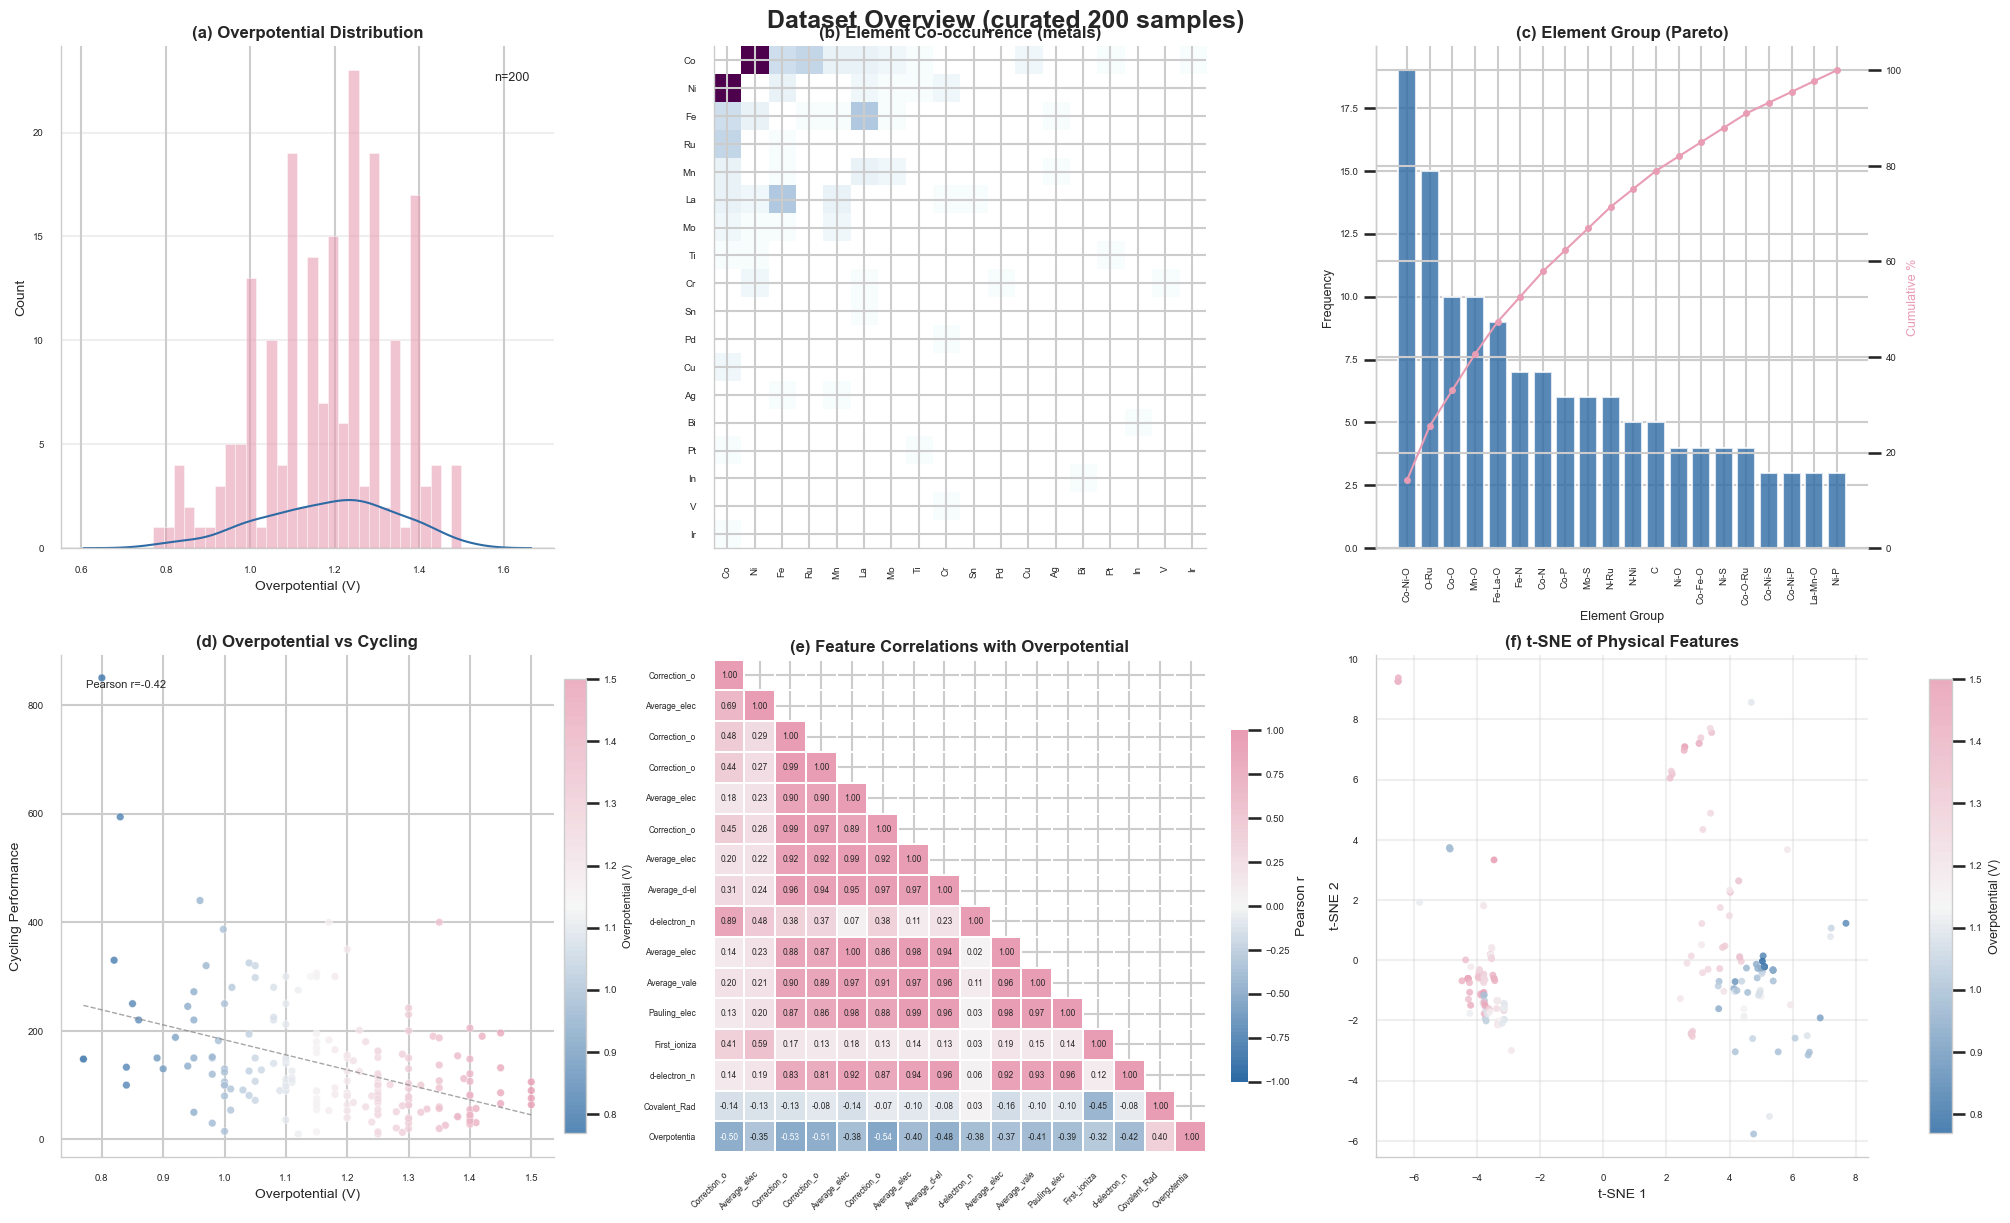

In [14]:
# --- 2x3 Comprehensive Overview Figure ---
fig, axes = plt.subplots(2, 3, figsize=(20, 12), constrained_layout=True)
fig.suptitle('Dataset Overview (curated 200 samples)', fontsize=18, weight='bold', y=1.01)

# (a) Overpotential distribution
ax = axes[0, 0]
ax.set_title('(a) Overpotential Distribution', fontsize=12, weight='bold')
perf = y_ov.dropna()
ax.hist(perf, bins=30, color=PINK, alpha=0.6, edgecolor='white', linewidth=0.5)
try:
    sns.kdeplot(perf, ax=ax, color=PRIMARY, linewidth=1.5)
except:
    pass
ax.set_xlabel('Overpotential (V)', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.text(0.95, 0.95, f'n={len(perf)}', transform=ax.transAxes, ha='right', va='top', fontsize=9)

# (b) Element co-occurrence heatmap
ax = axes[0, 1]
ax.set_title('(b) Element Co-occurrence (metals)', fontsize=12, weight='bold')
co_disp = co.astype(float)
co_disp[co_disp == 0] = np.nan
ax.imshow(co_disp, cmap='BuPu', interpolation='nearest', aspect='auto')
ax.set_xticks(range(len(elems))); ax.set_yticks(range(len(elems)))
ax.set_xticklabels(elems, rotation=90, fontsize=7)
ax.set_yticklabels(elems, fontsize=7)
# Colorbar handled after tight_layout

# (c) Element group Pareto
ax = axes[0, 2]
ax.set_title('(c) Element Group (Pareto)', fontsize=12, weight='bold')
groups = elem_grp[elem_grp.index != 'Unknown'].sort_values(ascending=False).head(20)
ax.bar(range(len(groups)), groups.values, color=PRIMARY, alpha=0.8)
ax.set_xticks(range(len(groups)))
ax.set_xticklabels([g if len(g)<10 else g[:10] for g in groups.index], rotation=90, fontsize=7)
ax.set_xlabel('Element Group', fontsize=9)
ax.set_ylabel('Frequency', fontsize=9)
ax_t = ax.twinx()
cs = np.cumsum(groups.values)
ax_t.plot(range(len(groups)), 100*cs/cs[-1], color=PINK, marker='o', linewidth=1.5, markersize=4)
ax_t.set_ylabel('Cumulative %', color=PINK, fontsize=9)
ax_t.set_ylim(0, 105)

# (d) Overpotential vs Cycling performance
ax = axes[1, 0]
ax.set_title('(d) Overpotential vs Cycling', fontsize=12, weight='bold')
if y_cp is not None:
    mask = y_ov.notna() & y_cp.notna()
    ov_v = y_ov[mask]; cp_v = y_cp[mask]
    sc = ax.scatter(ov_v, cp_v, c=ov_v, cmap=cmap_bp, s=30, alpha=0.8, edgecolors='white', linewidth=0.3)
    ax.set_xlabel('Overpotential (V)', fontsize=10)
    ax.set_ylabel('Cycling Performance', fontsize=10)
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.02).set_label('Overpotential (V)', fontsize=8)
    if len(ov_v) > 5:
        try:
            from scipy.stats import pearsonr
            pr, pp = pearsonr(ov_v, cp_v)
            m, b = np.polyfit(ov_v, cp_v, 1)
            xs = np.linspace(ov_v.min(), ov_v.max(), 100)
            ax.plot(xs, m*xs + b, color='grey', linestyle='--', linewidth=1, alpha=0.7)
            ax.text(0.05, 0.95, f'Pearson r={pr:.2f}', transform=ax.transAxes, fontsize=8, va='top')
        except:
            pass
else:
    ax.text(0.5, 0.5, 'No Cycling Performance data', ha='center', va='center', transform=ax.transAxes)

# (e) Spearman correlation heatmap (top features vs target)
ax = axes[1, 1]
ax.set_title('(e) Feature Correlations with Overpotential', fontsize=12, weight='bold')
sp_rows = []
y_full = y_ov.fillna(y_ov.median())
for col in ov_phys:
    xv = pd.to_numeric(X_ov[col], errors='coerce').fillna(0)
    try:
        r, p = spearmanr(xv, y_full)
    except:
        r, p = 0, 1
    sp_rows.append({'feature': col, 'rho': r, 'abs': abs(r)})
sp_df = pd.DataFrame(sp_rows).sort_values('abs', ascending=False)
top15 = sp_df.head(15)['feature'].tolist() + ['Overpotential(V)']
sub_corr = corr_mat.loc[top15, top15]
mask = np.triu(np.ones_like(sub_corr, dtype=bool), k=1)
sns.heatmap(sub_corr, mask=mask, cmap=cmap_bp, center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, annot=True, fmt='.2f',
            annot_kws={'size': 6}, cbar_kws={'shrink': 0.7, 'label': 'Pearson r'}, ax=ax)
ax.set_xticklabels([c[:12] for c in sub_corr.columns], rotation=45, ha='right', fontsize=6)
ax.set_yticklabels([c[:12] for c in sub_corr.columns], rotation=0, fontsize=6)

# (f) t-SNE colored by overpotential
ax = axes[1, 2]
ax.set_title('(f) t-SNE of Physical Features', fontsize=12, weight='bold')
sc = ax.scatter(X_ov_2d[:, 0], X_ov_2d[:, 1], c=y_ov, cmap=cmap_bp, s=25, alpha=0.85, edgecolors='none', rasterized=True)
fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.02).set_label('Overpotential (V)', fontsize=9)
ax.set_xlabel('t-SNE 1', fontsize=10)
ax.set_ylabel('t-SNE 2', fontsize=10)
ax.grid(alpha=0.3)

plt.savefig(OUT_DIR / 'comprehensive_3x2_overview_curated.png', dpi=350, bbox_inches='tight')
plt.savefig(OUT_DIR / 'comprehensive_3x2_overview_curated.pdf', bbox_inches='tight')
print('Saved: comprehensive_3x2_overview_curated.png/pdf')
plt.show()


# 7. Element selection

Co / Ni / Co-Ni OVERPOTENTIAL ANALYSIS

Sample distribution:
Category
Others    94
Co        53
Ni        26
Co-Ni     19
Ni-Co      8
Name: count, dtype: int64
TreeExplainer failed: could not convert string to float: '[1.18485E0]', fallback to xgboost pred_contribs


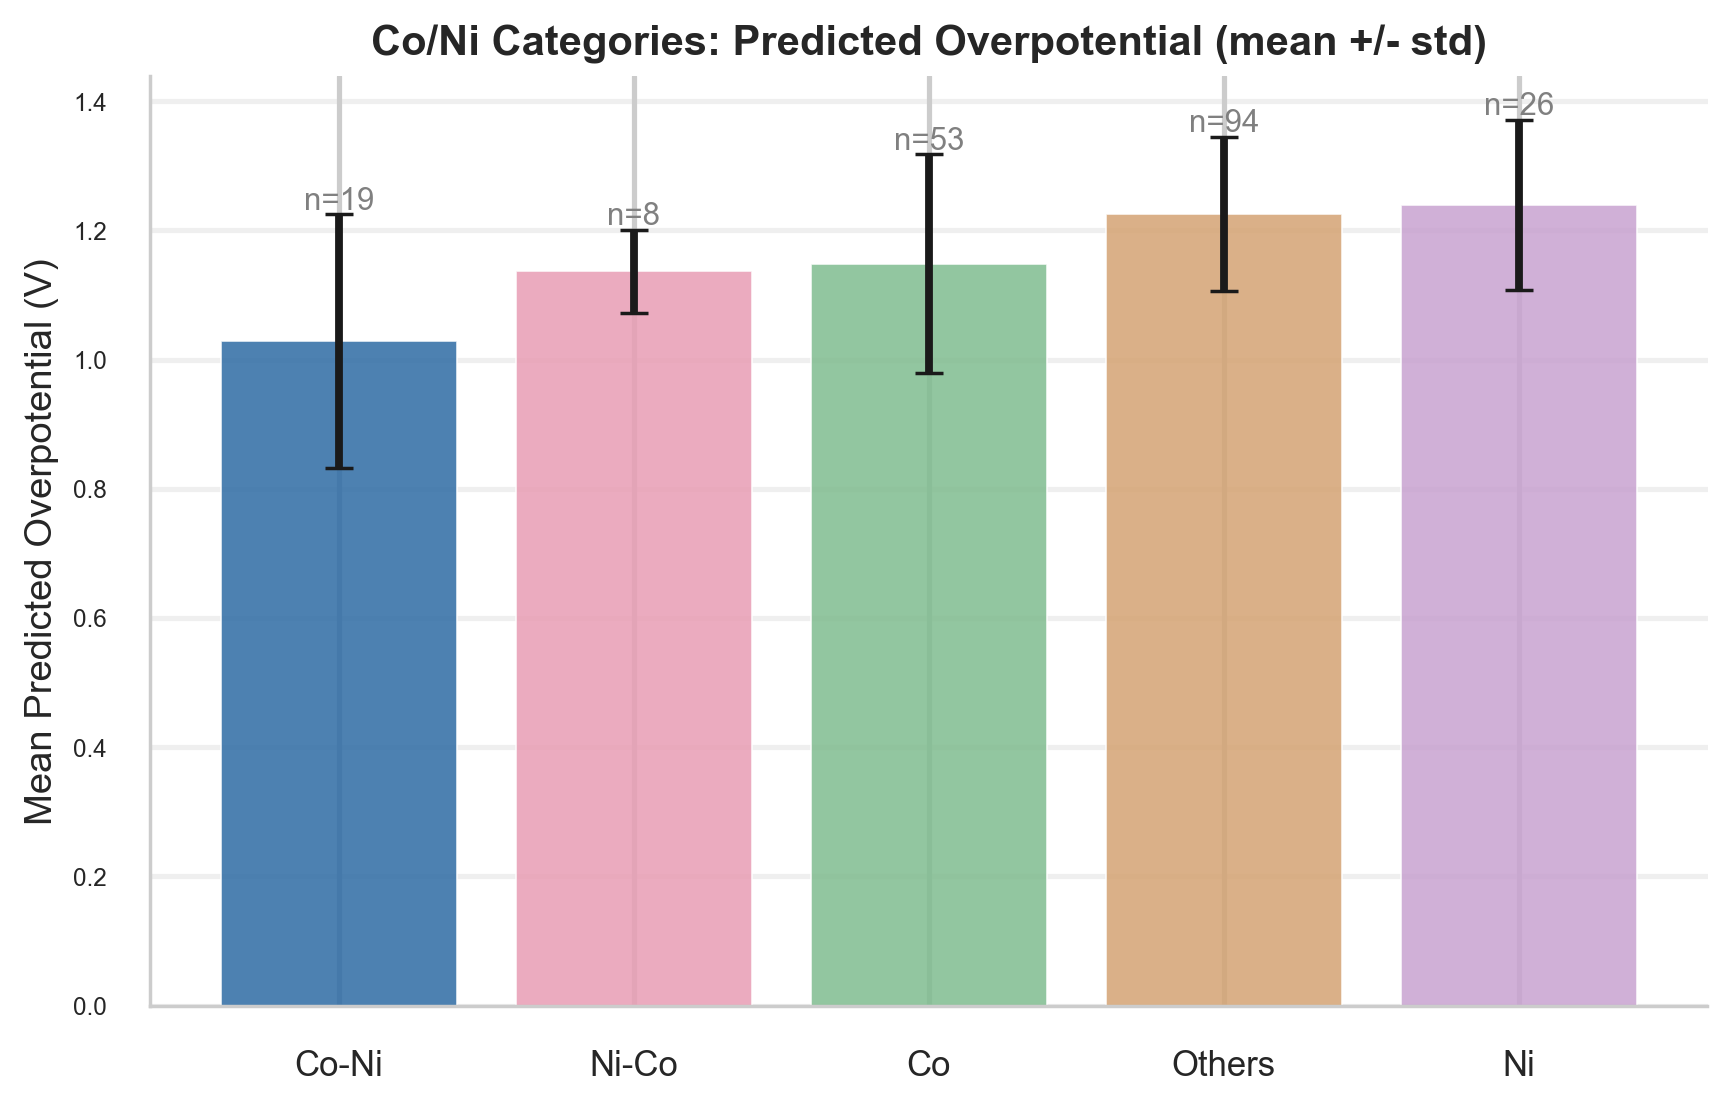


Ranking (by mean predicted overpotential, ascending):
  1. Co-Ni     mean=1.029V  std=0.196V  n=19
  2. Ni-Co     mean=1.137V  std=0.064V  n=8
  3. Co        mean=1.148V  std=0.17V  n=53
  4. Others    mean=1.225V  std=0.119V  n=94
  5. Ni        mean=1.239V  std=0.131V  n=26


In [15]:
print('='*60)
print('Co / Ni / Co-Ni OVERPOTENTIAL ANALYSIS')
print('='*60)

# --- Extract M1, M2 from compounds ---
df_ani = df.copy()
df_ani['M1'] = [extract_m1m2(c)[0] for c in df_ani['Compounds(M1-M2-N)']]
df_ani['M2'] = [extract_m1m2(c)[1] for c in df_ani['Compounds(M1-M2-N)']]
df_ani['Pred_Overpotential'] = best_model_output['best_estimator'].predict(X)

# --- Categorize into 5 groups ---
def categorize_simple(row):
    m1, m2 = row['M1'], row['M2']
    if m1 == 'Co' and m2 == 'Ni':   return 'Co-Ni'
    elif m1 == 'Ni' and m2 == 'Co': return 'Ni-Co'
    elif m1 == 'Co' or m2 == 'Co':  return 'Co'
    elif m1 == 'Ni' or m2 == 'Ni':  return 'Ni'
    else:                           return 'Others'

df_ani['Category'] = df_ani.apply(categorize_simple, axis=1)
print('\nSample distribution:')
print(df_ani['Category'].value_counts())

df_ani[['Compounds(M1-M2-N)', 'Overpotential(V)', 'M1', 'M2', 'Category', 'Pred_Overpotential']].to_csv(
    OUT_DIR / 'coni_category_data.csv', index=False, encoding='utf-8-sig')
# --- SHAP values ---
shap_model = tuning_outputs['xgboost']['best_estimator']
X_shap = X.apply(pd.to_numeric, errors='coerce').fillna(0.0).astype(np.float32)
try:
    explainer = shap.TreeExplainer(shap_model)
    shap_values_all = explainer.shap_values(X_shap)
except Exception as e:
    print(f'TreeExplainer failed: {e}, fallback to xgboost pred_contribs')
    booster = shap_model.get_booster()
    dmat = xgb.DMatrix(X_shap, feature_names=list(X_shap.columns))
    contrib = booster.predict(dmat, pred_contribs=True)
    shap_values_all = contrib[:, :-1]
if isinstance(shap_values_all, list):
    shap_values_all = shap_values_all[0]

# --- (1) Mean overpotential bar chart by category (sorted ascending) ---
cat_stats = df_ani.groupby('Category')['Pred_Overpotential'].agg(['mean', 'std', 'count'])
cat_stats = cat_stats.sort_values('mean')
cat_stats.to_csv(OUT_DIR / 'coni_category_stats.csv', encoding='utf-8-sig')

cat_colors = []
for cat in cat_stats.index:
    if cat == 'Co-Ni':    cat_colors.append(PRIMARY)
    elif cat == 'Ni-Co':  cat_colors.append(PINK)
    elif cat == 'Co':     cat_colors.append('#7FBC8F')
    elif cat == 'Ni':     cat_colors.append('#C8A2D0')
    else:                 cat_colors.append('#D4A373')

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=250)
ax.bar(range(len(cat_stats)), cat_stats['mean'], yerr=cat_stats['std'],
       color=cat_colors, edgecolor='white', linewidth=0.5, capsize=4, alpha=0.85)

for i, (idx, row) in enumerate(cat_stats.iterrows()):
    ax.text(i, row['mean'] + row['std'] + 0.008, 'n=' + str(int(row['count'])),
            ha='center', fontsize=9, color='grey')

ax.set_xticks(range(len(cat_stats)))
ax.set_xticklabels(cat_stats.index, fontsize=10)
ax.set_ylabel('Mean Predicted Overpotential (V)', fontsize=11)
ax.set_title('Co/Ni Categories: Predicted Overpotential (mean +/- std)', fontsize=12, weight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'coni_category_mean_ranking.png', dpi=350, bbox_inches='tight')
plt.savefig(OUT_DIR / 'coni_category_mean_ranking.pdf', bbox_inches='tight')
plt.show()

print('\nRanking (by mean predicted overpotential, ascending):')
for i, (idx, row) in enumerate(cat_stats.iterrows()):
    print('  ' + str(i+1) + '. ' + str(idx).ljust(8) + '  mean=' + str(round(row['mean'],3)) + 'V  std=' + str(round(row['std'],3)) + 'V  n=' + str(int(row['count'])))

Saved statistics to: coni_category_stats_with_ci95.csv


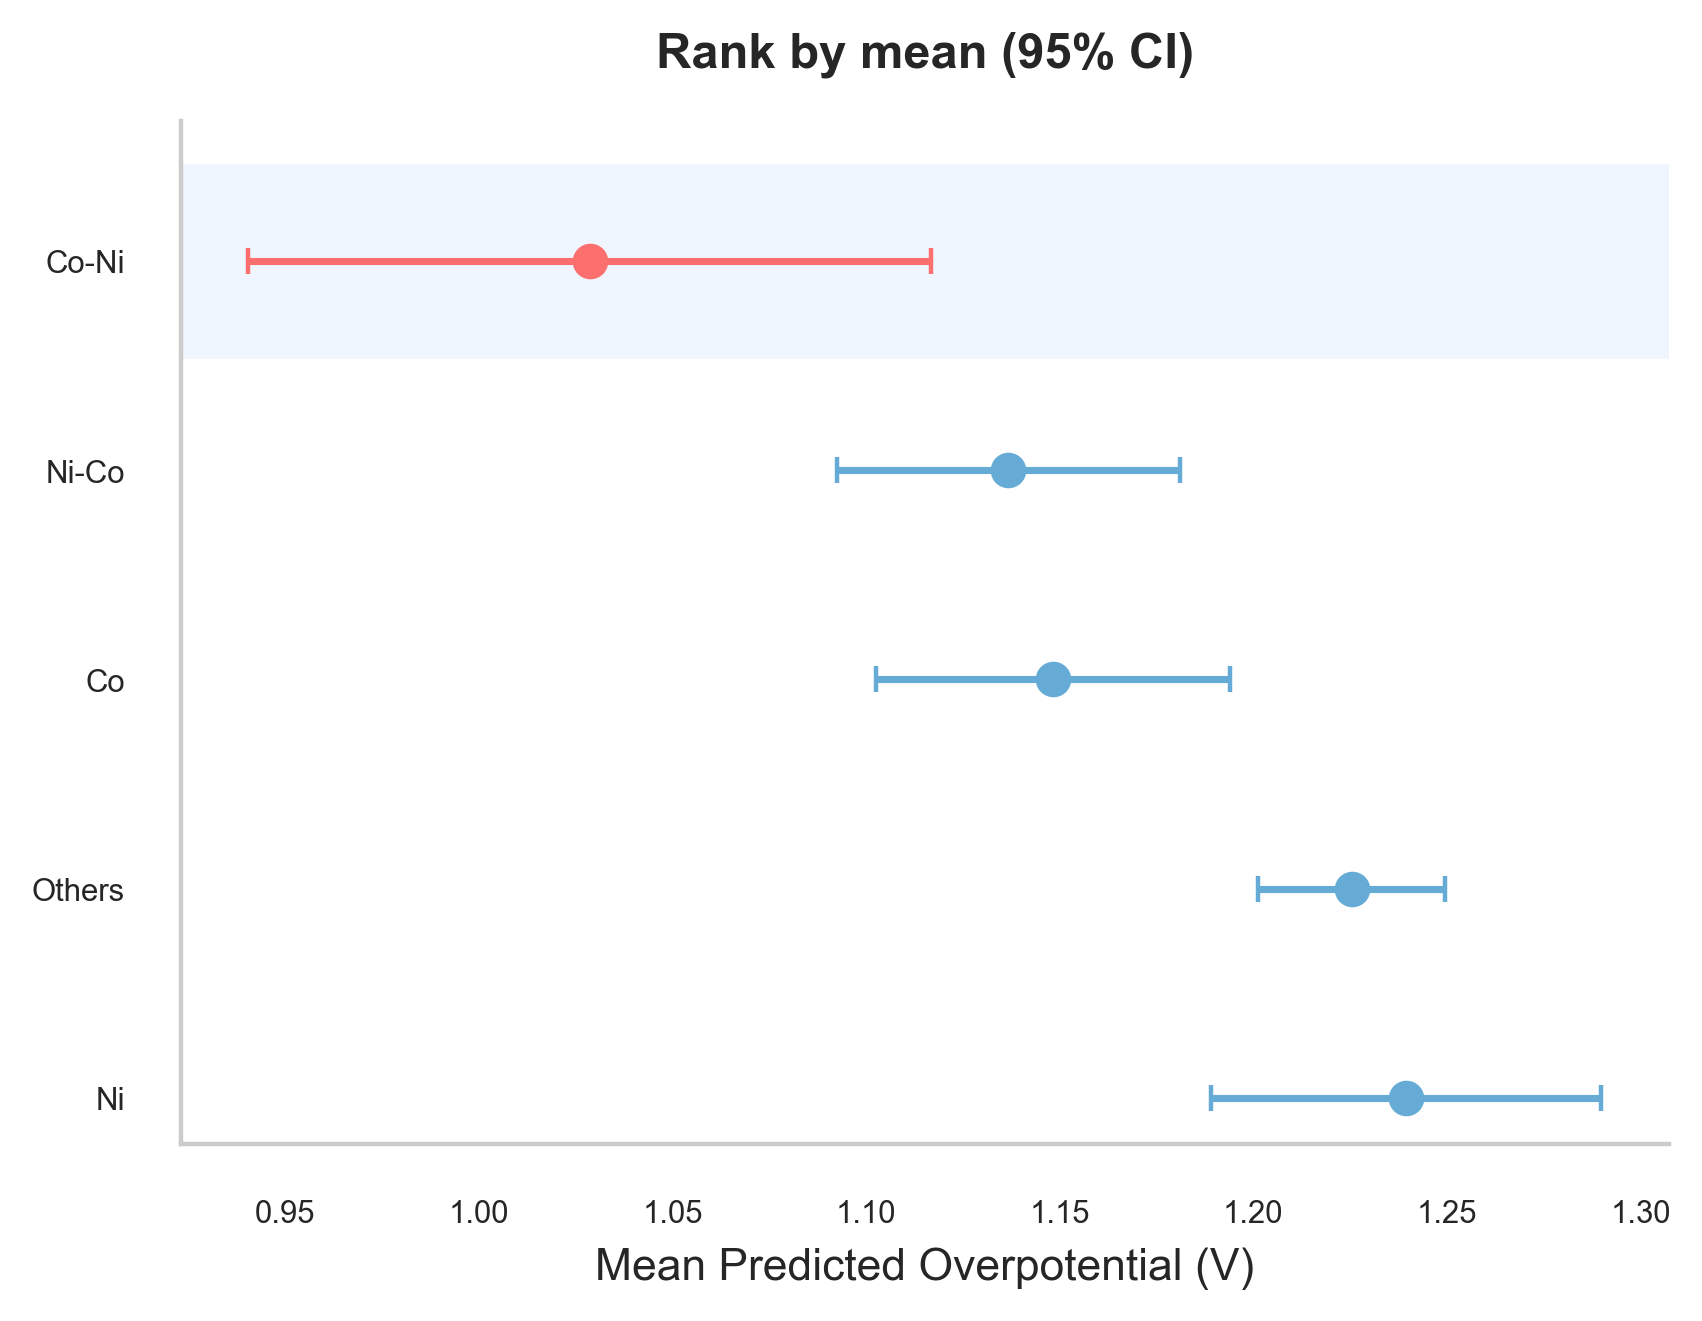

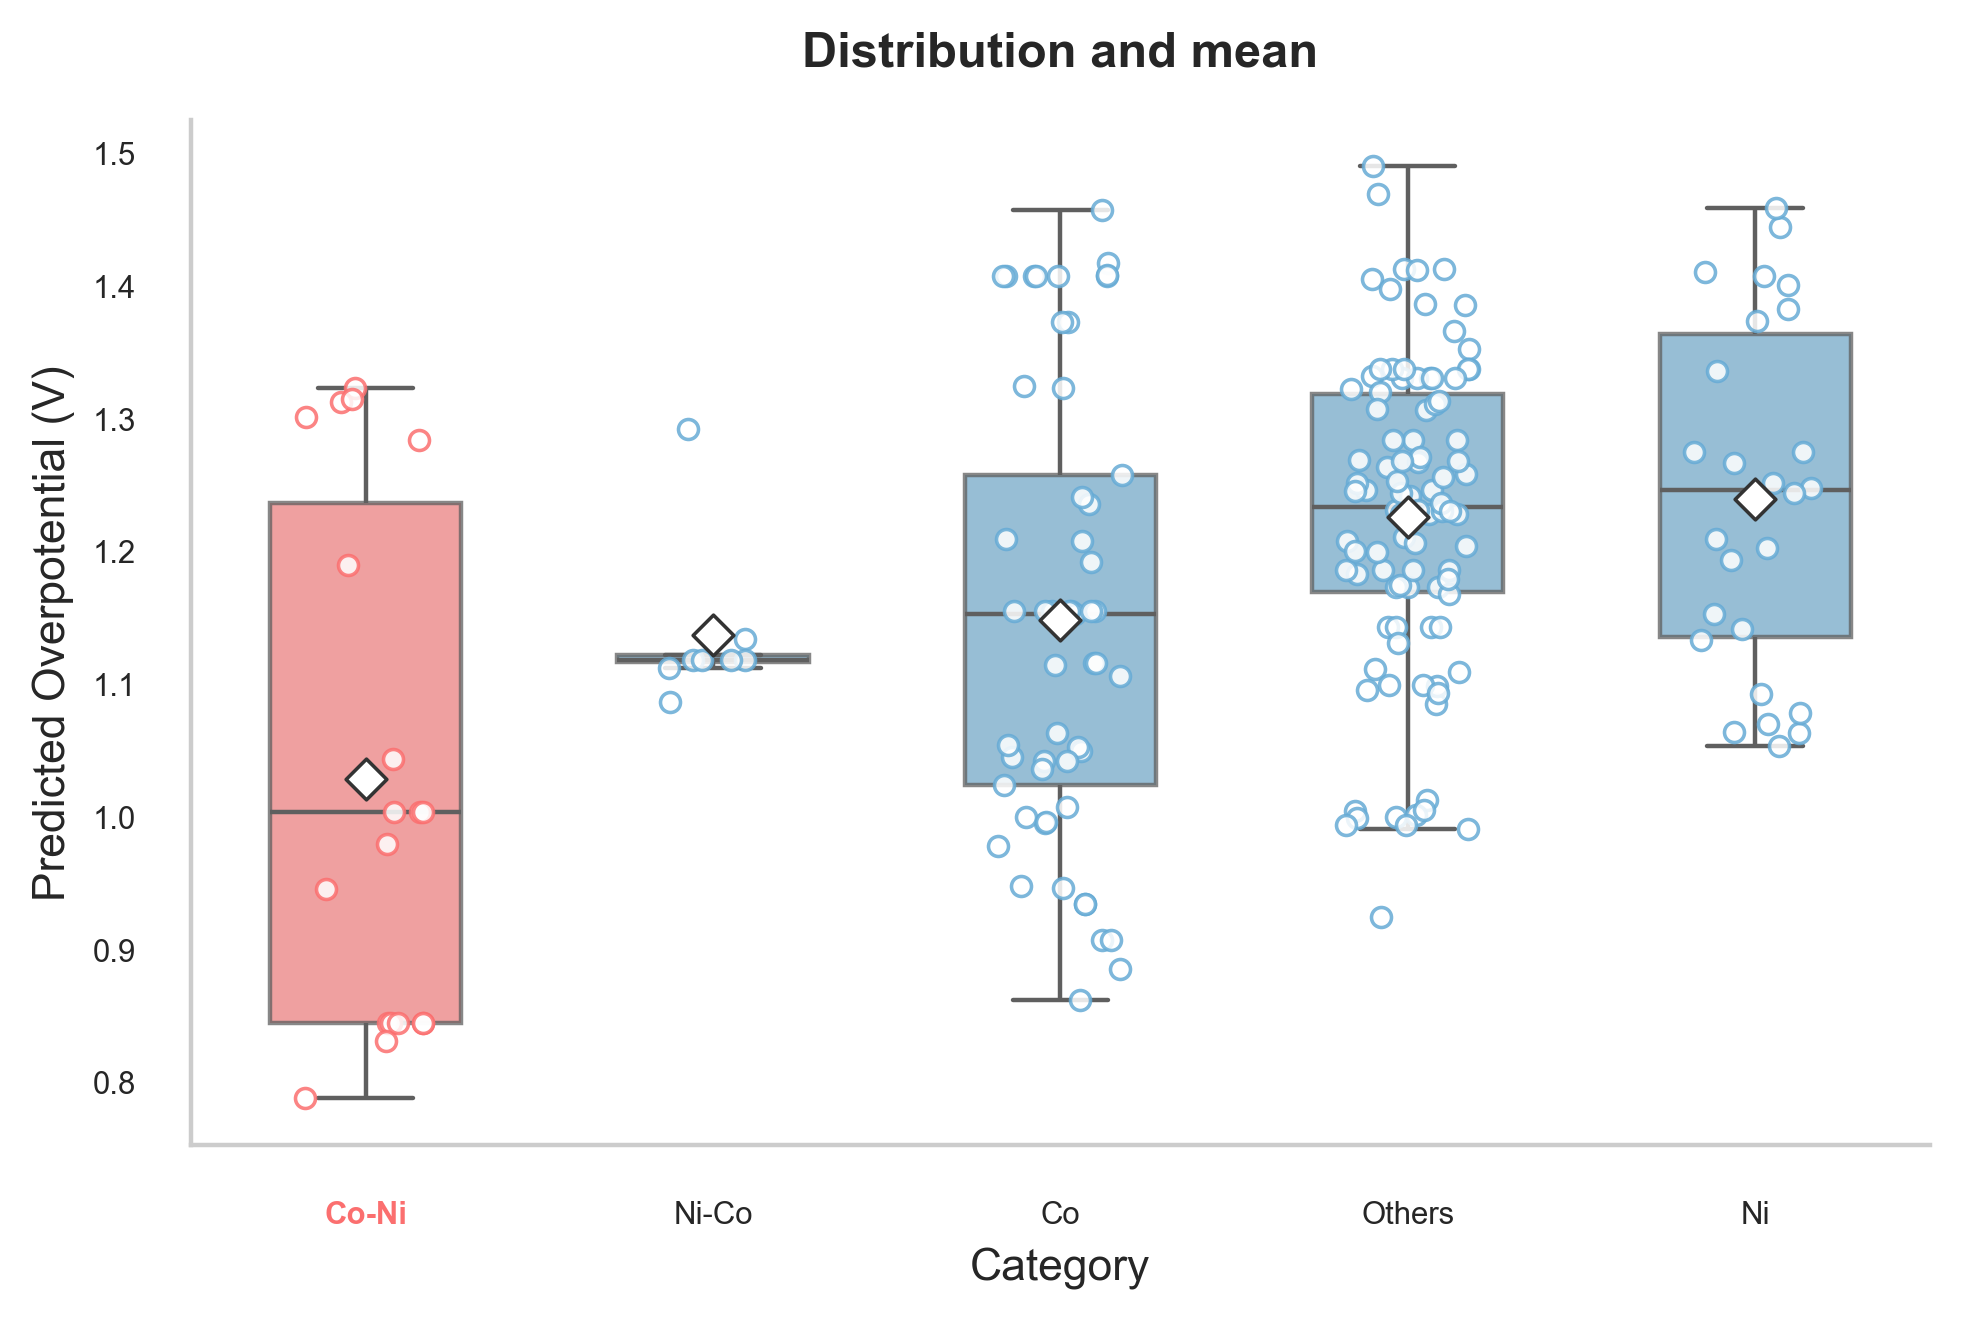

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df_ani[['Category', 'Pred_Overpotential']].copy().dropna()

order = plot_df.groupby('Category')['Pred_Overpotential'].mean().sort_values().index.tolist()
plot_df['Category'] = pd.Categorical(plot_df['Category'], categories=order, ordered=True)

stats_df = (
    plot_df.groupby('Category')['Pred_Overpotential']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .sort_values('mean', ascending=True)
    .reset_index(drop=True)
)
stats_df['sem'] = stats_df['std'] / np.sqrt(stats_df['count'].clip(lower=1))
stats_df['ci95'] = 1.96 * stats_df['sem']
stats_df['is_best'] = stats_df['Category'].eq('Co-Ni')

stats_df.to_csv(OUT_DIR / 'coni_category_stats_with_ci95.csv', index=False, encoding='utf-8-sig')
print('Saved statistics to: coni_category_stats_with_ci95.csv')

highlight = '#FB6F6F' 
neutral = '#66ABD5'   
palette = {c: (highlight if c == 'Co-Ni' else neutral) for c in order}


fig_a, ax_a = plt.subplots(figsize=(5.4, 4.2), dpi=320)
fig_a.patch.set_facecolor('white')
y = np.arange(len(stats_df))
for i, row in stats_df.iterrows():
    c = highlight if row['is_best'] else neutral
    ax_a.errorbar(
        x=row['mean'], y=i, xerr=row['ci95'], fmt='o',
        color=c, ecolor=c, elinewidth=1.6, capsize=3, markersize=7, zorder=3
    )
ax_a.set_yticks(y)
ax_a.set_yticklabels(stats_df['Category'])
ax_a.invert_yaxis()
ax_a.set_xlabel('Mean Predicted Overpotential (V)', fontsize=10)
ax_a.set_title('Rank by mean (95% CI)', fontsize=11, weight='bold', pad=12)
ax_a.grid(False)
for spine in ['top', 'right']:
    ax_a.spines[spine].set_visible(False)
ax_a.axhspan(-0.45, 0.45, color='#EEF5FF', alpha=0.9, zorder=0)
fig_a.tight_layout()
fig_a.savefig(OUT_DIR / 'coni_category_rank_mean_95CI.png', dpi=400, bbox_inches='tight', facecolor='white')
fig_a.savefig(OUT_DIR / 'coni_category_rank_mean_95CI.pdf', bbox_inches='tight', facecolor='white')
plt.show()



fig_b, ax_b = plt.subplots(figsize=(6.2, 4.2), dpi=320)
fig_b.patch.set_facecolor('white')
sns.boxplot(
    data=plot_df, x='Category', y='Pred_Overpotential', order=order,
    showfliers=False, linewidth=1.0, width=0.55,
    palette=[palette[c] for c in order], boxprops=dict(alpha=0.75), ax=ax_b
)

for cat in order:
    sub_df = plot_df[plot_df['Category'] == cat]
    current_color = palette[cat]
    
    sns.stripplot(
        data=sub_df, x='Category', y='Pred_Overpotential', order=order,
        size=4.5,                  
        jitter=0.18, 
        linewidth=0.8,             
        edgecolor=current_color,   
        facecolor='white',         
        alpha=0.85,                
        zorder=2.5,                
        ax=ax_b
    )

means = plot_df.groupby('Category')['Pred_Overpotential'].mean().reindex(order)
ax_b.scatter(np.arange(len(order)), means.values, marker='D', s=42, color='white', edgecolor='#333333', linewidth=0.8, zorder=4)

ax_b.set_xlabel('Category', fontsize=10)
ax_b.set_ylabel('Predicted Overpotential (V)', fontsize=10)
ax_b.set_title('Distribution and mean', fontsize=11, weight='bold', pad=12)

ax_b.grid(False)
for spine in ['top', 'right']:
    ax_b.spines[spine].set_visible(False)

for label in ax_b.get_xticklabels():
    if label.get_text() == 'Co-Ni':
        label.set_color(highlight)
        label.set_fontweight('bold')

fig_b.tight_layout()
fig_b.savefig(OUT_DIR / 'coni_category_distribution_box.png', dpi=400, bbox_inches='tight', facecolor='white')
fig_b.savefig(OUT_DIR / 'coni_category_distribution_box.pdf', bbox_inches='tight', facecolor='white')
plt.show()


boxplot_results = []

for cat in order:
    cat_series = plot_df[plot_df['Category'] == cat]['Pred_Overpotential']
    
    q1 = cat_series.quantile(0.25)
    median = cat_series.quantile(0.50)
    q3 = cat_series.quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    actual_lower = cat_series[cat_series >= lower_limit].min()
    actual_upper = cat_series[cat_series <= upper_limit].max()

    mean_val = cat_series.mean()
    
    boxplot_results.append({
        'Category': cat,
        'Min_Whisker ': actual_lower,
        '25%_Quantile ': q1,
        '50%_Median': median,
        'Mean': mean_val,
        '75%_Quantile ': q3,
        'Max_Whisker': actual_upper,
        'Data_Count': cat_series.count()
    })

boxplot_df = pd.DataFrame(boxplot_results)
boxplot_df.to_csv(OUT_DIR / 'coni_category_boxplot_values.csv', index=False, encoding='utf-8-sig')



raw_elements_export = []

for cat in order:
    sub_df = df_ani[df_ani['Category'] == cat].copy()
    raw_elements_export.append(sub_df)

all_raw_elements = pd.concat(raw_elements_export, ignore_index=True)
all_raw_elements.to_csv(OUT_DIR / 'coni_category_b_plots_raw_elements.csv', index=True, encoding='utf-8-sig')